# 🏀 March Machine Learning Mania 2026 — EDA & Feature Engineering

**Objective:** Predict the probability that the lower-seeded TeamID wins for every possible NCAA Division I Men's & Women's tournament matchup.

**Evaluation:** Brier Score (equivalent to MSE on probabilities).

**Key dates:**  
- Submission covers every possible 2026 matchup  
- Leaderboard reflects 2021-2025 historical scores until the 2026 tournaments begin

---

### Notebook Roadmap
1. **Data Loading & Overview** — Load all datasets, inspect shapes, types, missing values  
2. **EDA — Men's Data** — Season trends, score distributions, seed analysis, upsets  
3. **EDA — Women's Data** — Same structure for women's tournaments  
4. **Feature Engineering** — Team-level season stats, advanced metrics, ranking features, conference strength  
5. **Feature Selection** — Correlation analysis, mutual information, variance thresholds  
6. **Submission Skeleton** — Prepare the prediction dataframe

In [6]:
# ============================================================
# 1. IMPORTS & CONFIGURATION
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

DATA_DIR = Path("/kaggle/input/competitions/march-machine-learning-mania-2026")
CURRENT_SEASON = 2026
print("✅ Libraries loaded")

✅ Libraries loaded


In [7]:
# ============================================================
# 2. DATA LOADING
# ============================================================

# --- Section 1: The Basics ---
m_teams     = pd.read_csv(DATA_DIR / "MTeams.csv")
w_teams     = pd.read_csv(DATA_DIR / "WTeams.csv")
m_seasons   = pd.read_csv(DATA_DIR / "MSeasons.csv")
w_seasons   = pd.read_csv(DATA_DIR / "WSeasons.csv")
m_seeds     = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds     = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")
m_reg       = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg       = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")
m_tourney   = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney   = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
sub_stage1  = pd.read_csv(DATA_DIR / "SampleSubmissionStage1.csv")
sub_stage2  = pd.read_csv(DATA_DIR / "SampleSubmissionStage2.csv")

# --- Section 2: Detailed Box Scores ---
m_reg_det   = pd.read_csv(DATA_DIR / "MRegularSeasonDetailedResults.csv")
w_reg_det   = pd.read_csv(DATA_DIR / "WRegularSeasonDetailedResults.csv")
m_tour_det  = pd.read_csv(DATA_DIR / "MNCAATourneyDetailedResults.csv")
w_tour_det  = pd.read_csv(DATA_DIR / "WNCAATourneyDetailedResults.csv")

# --- Section 3: Geography ---
cities      = pd.read_csv(DATA_DIR / "Cities.csv")
m_game_cities = pd.read_csv(DATA_DIR / "MGameCities.csv")
w_game_cities = pd.read_csv(DATA_DIR / "WGameCities.csv")

# --- Section 4: Rankings (Men only) ---
massey      = pd.read_csv(DATA_DIR / "MMasseyOrdinals.csv")

# --- Section 5: Supplements ---
coaches     = pd.read_csv(DATA_DIR / "MTeamCoaches.csv")
conferences = pd.read_csv(DATA_DIR / "Conferences.csv")
m_team_conf = pd.read_csv(DATA_DIR / "MTeamConferences.csv")
w_team_conf = pd.read_csv(DATA_DIR / "WTeamConferences.csv")
m_conf_tourney = pd.read_csv(DATA_DIR / "MConferenceTourneyGames.csv")
w_conf_tourney = pd.read_csv(DATA_DIR / "WConferenceTourneyGames.csv")
m_slots     = pd.read_csv(DATA_DIR / "MNCAATourneySlots.csv")
w_slots     = pd.read_csv(DATA_DIR / "WNCAATourneySlots.csv")
m_seed_slots = pd.read_csv(DATA_DIR / "MNCAATourneySeedRoundSlots.csv")
m_secondary = pd.read_csv(DATA_DIR / "MSecondaryTourneyCompactResults.csv")
w_secondary = pd.read_csv(DATA_DIR / "WSecondaryTourneyCompactResults.csv")
m_sec_teams = pd.read_csv(DATA_DIR / "MSecondaryTourneyTeams.csv")
w_sec_teams = pd.read_csv(DATA_DIR / "WSecondaryTourneyTeams.csv")
m_spellings = pd.read_csv(DATA_DIR / "MTeamSpellings.csv", encoding="latin-1")
w_spellings = pd.read_csv(DATA_DIR / "WTeamSpellings.csv", encoding="latin-1")

print("✅ All datasets loaded")

✅ All datasets loaded


## 2.1 Dataset Overview — Shapes, Types & Missing Values

In [8]:
# Quick summary of every loaded dataframe
all_dfs = {
    "MTeams": m_teams, "WTeams": w_teams,
    "MSeasons": m_seasons, "WSeasons": w_seasons,
    "MSeeds": m_seeds, "WSeeds": w_seeds,
    "MRegSeason": m_reg, "WRegSeason": w_reg,
    "MTourney": m_tourney, "WTourney": w_tourney,
    "MRegDetailed": m_reg_det, "WRegDetailed": w_reg_det,
    "MTourneyDetailed": m_tour_det, "WTourneyDetailed": w_tour_det,
    "MasseyOrdinals": massey,
    "Coaches": coaches,
    "MTeamConf": m_team_conf, "WTeamConf": w_team_conf,
    "Conferences": conferences,
    "Cities": cities,
    "MGameCities": m_game_cities, "WGameCities": w_game_cities,
    "SampleSub1": sub_stage1, "SampleSub2": sub_stage2,
}

summary_rows = []
for name, df in all_dfs.items():
    summary_rows.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Cols": df.shape[1],
        "Missing": df.isnull().sum().sum(),
        "Columns": ", ".join(df.columns[:8]) + ("..." if df.shape[1] > 8 else ""),
        "Season Range": f"{df['Season'].min()}-{df['Season'].max()}" if "Season" in df.columns else "N/A"
    })

overview = pd.DataFrame(summary_rows)
overview.style.set_caption("Dataset Overview").hide(axis="index")

Dataset,Rows,Cols,Missing,Columns,Season Range
MTeams,381,4,0,"TeamID, TeamName, FirstD1Season, LastD1Season",N/A
WTeams,379,2,0,"TeamID, TeamName",N/A
MSeasons,42,6,0,"Season, DayZero, RegionW, RegionX, RegionY, RegionZ",1985-2026
WSeasons,29,6,0,"Season, DayZero, RegionW, RegionX, RegionY, RegionZ",1998-2026
MSeeds,2626,3,0,"Season, Seed, TeamID",1985-2025
WSeeds,1744,3,0,"Season, Seed, TeamID",1998-2025
MRegSeason,198079,8,0,"Season, DayNum, WTeamID, WScore, LTeamID, LScore, WLoc, NumOT",1985-2026
WRegSeason,142093,8,0,"Season, DayNum, WTeamID, WScore, LTeamID, LScore, WLoc, NumOT",1998-2026
MTourney,2585,8,0,"Season, DayNum, WTeamID, WScore, LTeamID, LScore, WLoc, NumOT",1985-2025
WTourney,1717,8,0,"Season, DayNum, WTeamID, WScore, LTeamID, LScore, WLoc, NumOT",1998-2025


In [9]:
# Detailed look at Men's regular season compact results
print("MRegularSeasonCompactResults")
print(m_reg.info())
m_reg.head()

MRegularSeasonCompactResults
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198079 entries, 0 to 198078
Data columns (total 8 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   Season   198079 non-null  int64 
 1   DayNum   198079 non-null  int64 
 2   WTeamID  198079 non-null  int64 
 3   WScore   198079 non-null  int64 
 4   LTeamID  198079 non-null  int64 
 5   LScore   198079 non-null  int64 
 6   WLoc     198079 non-null  object
 7   NumOT    198079 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 12.1+ MB
None


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0


In [10]:
# Detailed look at box score columns
print("MRegularSeasonDetailedResults — Extra columns beyond compact:")
print(m_reg_det.columns[8:].tolist())
m_reg_det.head(3)

MRegularSeasonDetailedResults — Extra columns beyond compact:
['WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23


---
## 3. EDA — Men's Tournament Data

### 3.1 Games Per Season & Score Distributions

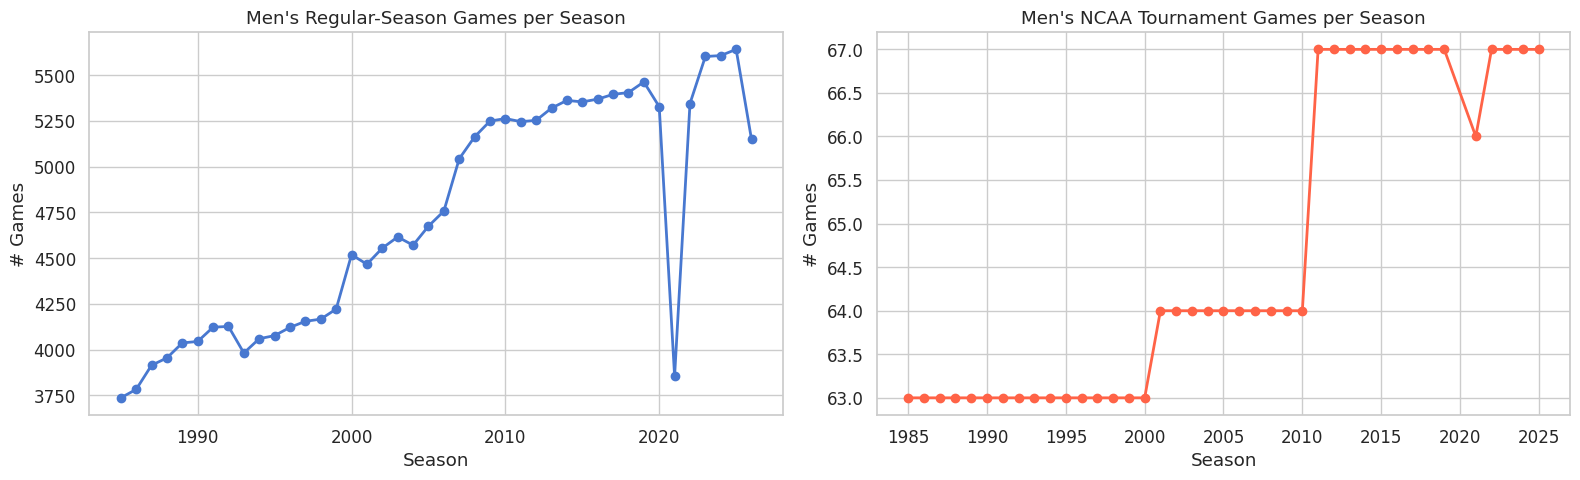

In [11]:
# 3.1a  Number of regular-season & tournament games per season (Men)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

m_reg.groupby("Season").size().plot(ax=axes[0], marker="o", linewidth=2)
axes[0].set_title("Men's Regular-Season Games per Season")
axes[0].set_ylabel("# Games")

m_tourney.groupby("Season").size().plot(ax=axes[1], marker="o", linewidth=2, color="tomato")
axes[1].set_title("Men's NCAA Tournament Games per Season")
axes[1].set_ylabel("# Games")
plt.tight_layout()
plt.show()

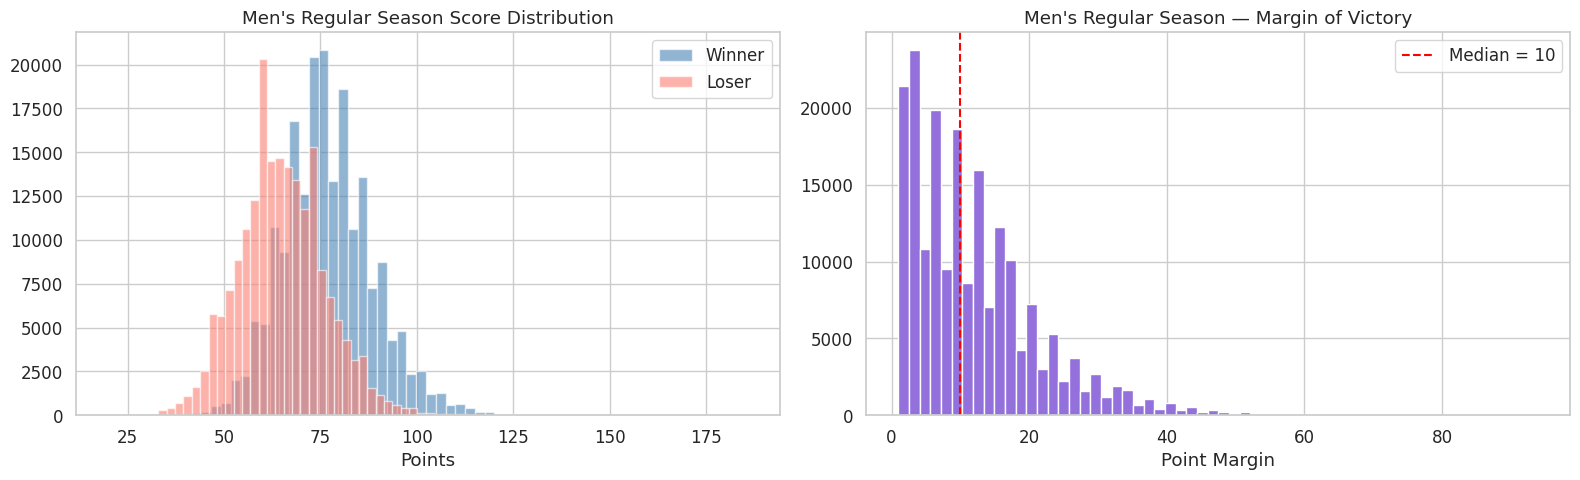

Average winning score: 77.0 | Average losing score: 64.9
Average margin: 12.1 | Median margin: 10


In [12]:
# 3.1b  Score distributions — winning vs losing (Men's regular season)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(m_reg["WScore"], bins=60, alpha=0.6, label="Winner", color="steelblue")
axes[0].hist(m_reg["LScore"], bins=60, alpha=0.6, label="Loser", color="salmon")
axes[0].set_title("Men's Regular Season Score Distribution")
axes[0].set_xlabel("Points")
axes[0].legend()

# Margin of victory
m_reg["Margin"] = m_reg["WScore"] - m_reg["LScore"]
axes[1].hist(m_reg["Margin"], bins=60, color="mediumpurple", edgecolor="white")
axes[1].set_title("Men's Regular Season — Margin of Victory")
axes[1].set_xlabel("Point Margin")
axes[1].axvline(m_reg["Margin"].median(), color="red", linestyle="--", label=f"Median = {m_reg['Margin'].median():.0f}")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Average winning score: {m_reg['WScore'].mean():.1f} | Average losing score: {m_reg['LScore'].mean():.1f}")
print(f"Average margin: {m_reg['Margin'].mean():.1f} | Median margin: {m_reg['Margin'].median():.0f}")

### 3.2 Seed Analysis — How predictive are tournament seeds?

In [13]:
# Parse seed number from the seed string (e.g., "W01a" -> 1)
def parse_seed(seed_str):
    return int(seed_str[1:3])

m_seeds["SeedNum"] = m_seeds["Seed"].apply(parse_seed)
w_seeds["SeedNum"] = w_seeds["Seed"].apply(parse_seed)

# Merge seeds onto tournament results
m_tour_seeds = (
    m_tourney
    .merge(m_seeds[["Season","TeamID","SeedNum"]], left_on=["Season","WTeamID"], right_on=["Season","TeamID"])
    .rename(columns={"SeedNum": "WSeed"})
    .drop(columns="TeamID")
    .merge(m_seeds[["Season","TeamID","SeedNum"]], left_on=["Season","LTeamID"], right_on=["Season","TeamID"])
    .rename(columns={"SeedNum": "LSeed"})
    .drop(columns="TeamID")
)
m_tour_seeds["SeedDiff"] = m_tour_seeds["WSeed"] - m_tour_seeds["LSeed"]  # negative = higher seed won

print(f"Men's tournament games with seeds: {len(m_tour_seeds)}")
m_tour_seeds[["Season","WTeamID","LTeamID","WScore","LScore","WSeed","LSeed","SeedDiff"]].head(10)

Men's tournament games with seeds: 2585


,Season,WTeamID,LTeamID,WScore,LScore,WSeed,LSeed,SeedDiff
0,1985,1116,1234,63,54,9,8,1
1,1985,1120,1345,59,58,11,6,5
2,1985,1207,1250,68,43,1,16,-15
3,1985,1229,1425,58,55,9,8,1
4,1985,1242,1325,49,38,3,14,-11
5,1985,1246,1449,66,58,12,5,7
6,1985,1256,1338,78,54,5,12,-7
7,1985,1260,1233,59,58,4,13,-9
8,1985,1314,1292,76,57,2,15,-13
9,1985,1323,1333,79,70,7,10,-3


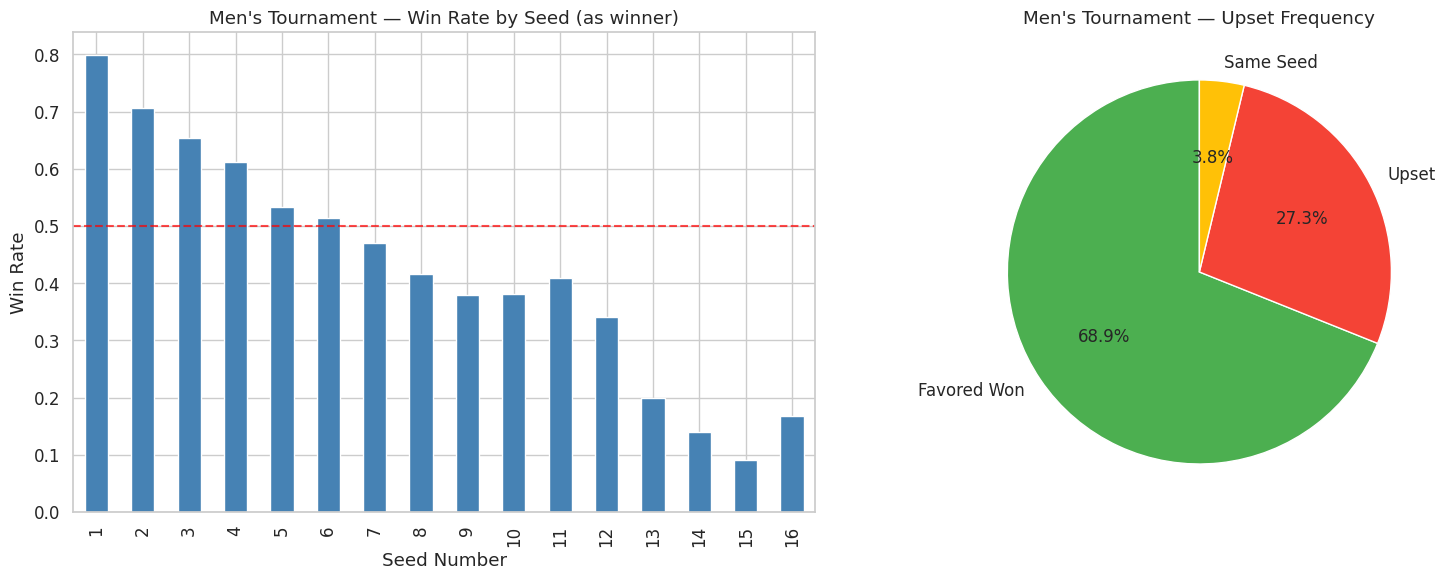

Upset rate (higher seed beats lower seed): 28.4%


In [14]:
# Seed matchup win rates — how often does the better seed win?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Win rate by winner's seed
wseed_wins = m_tour_seeds.groupby("WSeed").size()
lseed_losses = m_tour_seeds.groupby("LSeed").size()
seed_total = wseed_wins.add(lseed_losses, fill_value=0)
seed_win_rate = (wseed_wins / seed_total).sort_index()

seed_win_rate.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Men's Tournament — Win Rate by Seed (as winner)")
axes[0].set_xlabel("Seed Number")
axes[0].set_ylabel("Win Rate")
axes[0].axhline(0.5, color="red", linestyle="--", alpha=0.7)

# Upset rate: higher seed number beating lower seed number
upsets = m_tour_seeds[m_tour_seeds["WSeed"] > m_tour_seeds["LSeed"]]
normal = m_tour_seeds[m_tour_seeds["WSeed"] < m_tour_seeds["LSeed"]]
equal  = m_tour_seeds[m_tour_seeds["WSeed"] == m_tour_seeds["LSeed"]]

labels = ["Favored Won", "Upset", "Same Seed"]
sizes = [len(normal), len(upsets), len(equal)]
colors = ["#4CAF50", "#F44336", "#FFC107"]
axes[1].pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Men's Tournament — Upset Frequency")

plt.tight_layout()
plt.show()
print(f"Upset rate (higher seed beats lower seed): {len(upsets) / (len(upsets) + len(normal)):.1%}")

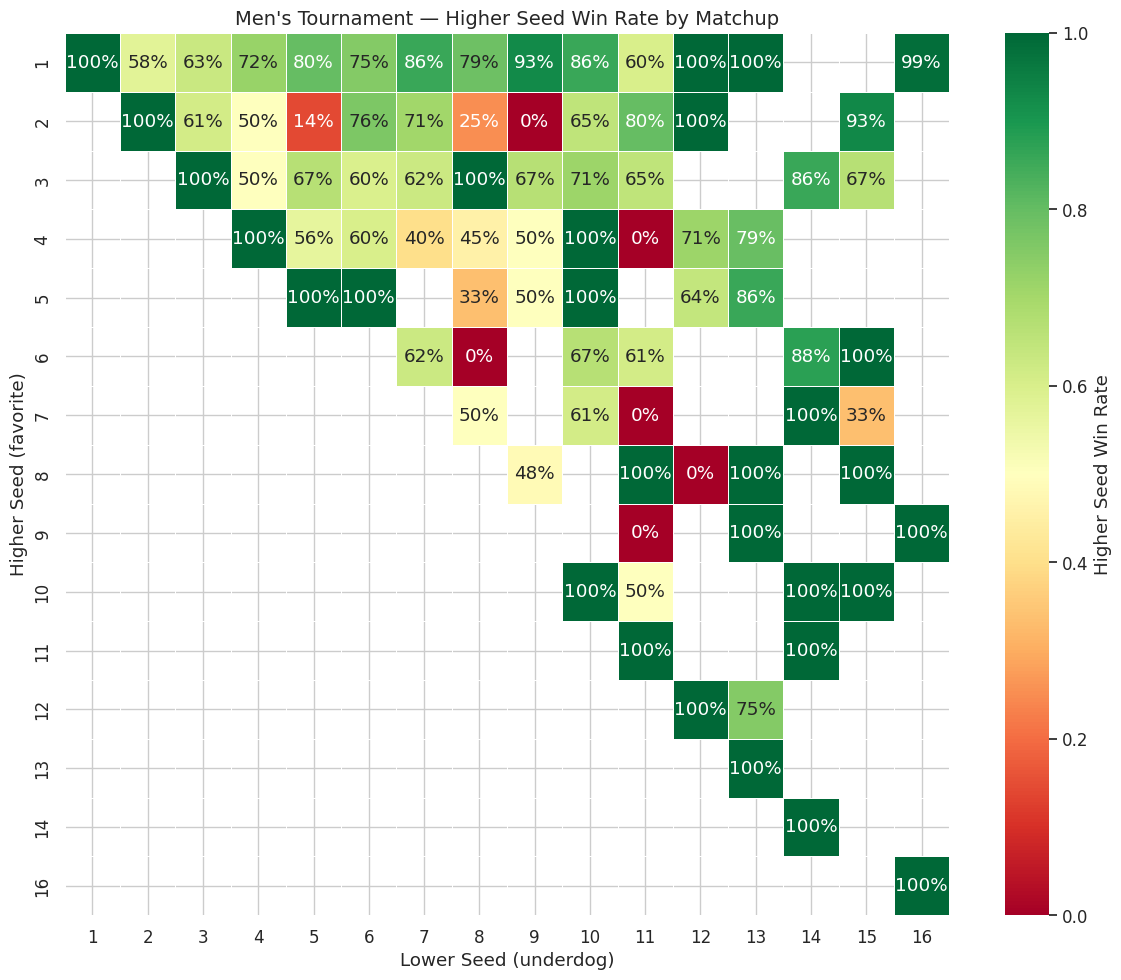

In [15]:
# Classic seed matchup heatmap (Men's)
# For each (higher_seed, lower_seed) matchup, compute win rate for the higher seed
matchup_data = m_tour_seeds.copy()
matchup_data["HighSeed"] = matchup_data[["WSeed","LSeed"]].min(axis=1)
matchup_data["LowSeed"]  = matchup_data[["WSeed","LSeed"]].max(axis=1)
matchup_data["HighSeedWon"] = (matchup_data["WSeed"] == matchup_data["HighSeed"]).astype(int)

pivot = matchup_data.groupby(["HighSeed","LowSeed"])["HighSeedWon"].agg(["mean","count"]).reset_index()
pivot_wide = pivot.pivot(index="HighSeed", columns="LowSeed", values="mean")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pivot_wide, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Higher Seed Win Rate"})
ax.set_title("Men's Tournament — Higher Seed Win Rate by Matchup", fontsize=14)
ax.set_xlabel("Lower Seed (underdog)")
ax.set_ylabel("Higher Seed (favorite)")
plt.tight_layout()
plt.show()

### 3.3 Home-Court Advantage & Overtime Analysis

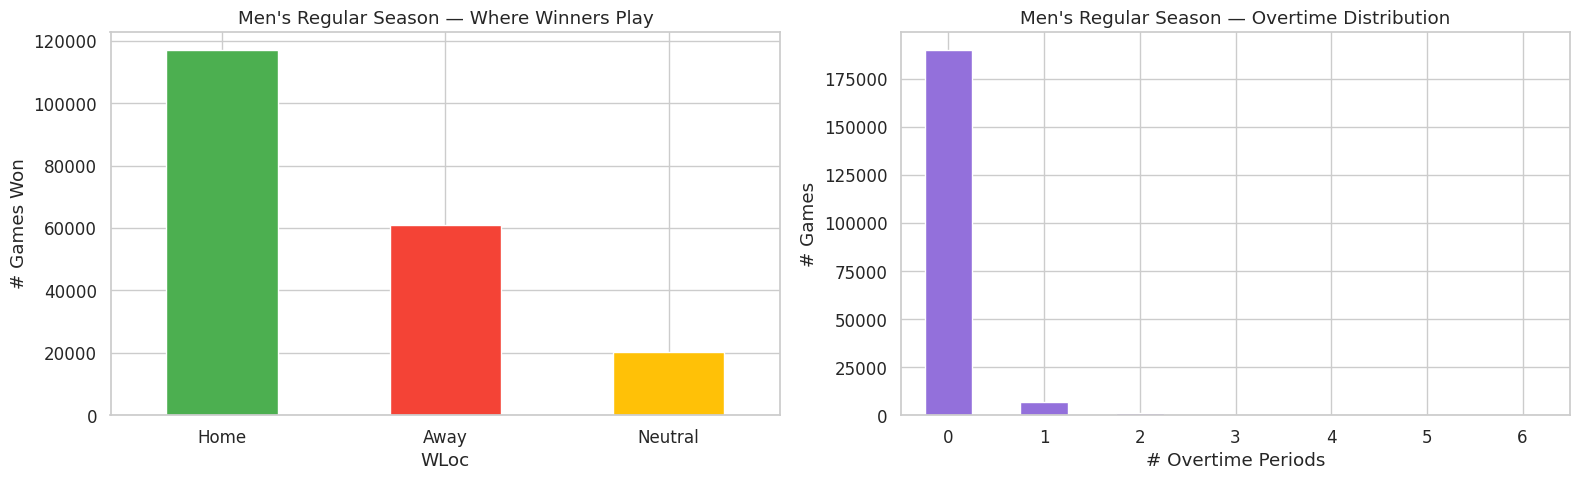

Home team wins: 59.1% of regular season games
Games going to OT: 4.1%


In [16]:
# Home-court advantage in regular season (Men's)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

loc_counts = m_reg["WLoc"].value_counts()
loc_labels = {"H": "Home", "A": "Away", "N": "Neutral"}
loc_counts.index = loc_counts.index.map(loc_labels)
loc_counts.plot(kind="bar", ax=axes[0], color=["#4CAF50","#F44336","#FFC107"], edgecolor="white")
axes[0].set_title("Men's Regular Season — Where Winners Play")
axes[0].set_ylabel("# Games Won")
axes[0].tick_params(axis="x", rotation=0)

# Overtime distribution
ot_counts = m_reg["NumOT"].value_counts().sort_index()
ot_counts.plot(kind="bar", ax=axes[1], color="mediumpurple", edgecolor="white")
axes[1].set_title("Men's Regular Season — Overtime Distribution")
axes[1].set_xlabel("# Overtime Periods")
axes[1].set_ylabel("# Games")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

pct_home = loc_counts.get("Home", 0) / loc_counts.sum()
print(f"Home team wins: {pct_home:.1%} of regular season games")
print(f"Games going to OT: {(m_reg['NumOT'] > 0).mean():.1%}")

### 3.4 Massey Ordinal Rankings — Top Systems & Correlation with Tournament Success

In [17]:
# How many ranking systems are there? Which are most prevalent?
print(f"Total ranking systems: {massey['SystemName'].nunique()}")
print(f"\nTop 15 systems by number of observations:")
print(massey["SystemName"].value_counts().head(15))

# Get the final pre-tournament rankings (RankingDayNum=133) for recent seasons
massey_final = massey[massey["RankingDayNum"] == 133].copy()
print(f"\nFinal pre-tournament rankings: {len(massey_final)} rows covering {massey_final['Season'].nunique()} seasons")
print(f"Systems with final rankings: {massey_final['SystemName'].nunique()}")

Total ranking systems: 196

Top 15 systems by number of observations:
SystemName
MOR    149380
POM    146889
DOK    133593
SAG    130371
MAS    123287
WLK    119917
WIL    118642
PGH    117378
DOL    117079
COL    110817
KPK    106942
BIH    103235
DUN    101616
WOL     93494
RTH     92961
Name: count, dtype: int64

Final pre-tournament rankings: 395154 rows covering 22 seasons
Systems with final rankings: 181


In [18]:
# Which ranking systems best predict tournament outcomes? 
# Compare final pre-tournament rank of winner vs loser
key_systems = ["POM", "SAG", "MOR", "DOL", "COL", "RPI", "SEL", "WOL", "AP", "USA"]
systems_available = massey_final["SystemName"].unique()
key_systems = [s for s in key_systems if s in systems_available]

# Merge rankings onto tournament games for each system
rank_accuracy = {}
for sys_name in key_systems:
    sys_ranks = massey_final[massey_final["SystemName"] == sys_name][["Season","TeamID","OrdinalRank"]]
    merged = (
        m_tourney
        .merge(sys_ranks, left_on=["Season","WTeamID"], right_on=["Season","TeamID"], how="inner")
        .rename(columns={"OrdinalRank": "WRank"})
        .drop(columns="TeamID")
        .merge(sys_ranks, left_on=["Season","LTeamID"], right_on=["Season","TeamID"], how="inner")
        .rename(columns={"OrdinalRank": "LRank"})
        .drop(columns="TeamID")
    )
    # Better rank = lower number; winner should have lower rank if system is good
    correct = (merged["WRank"] < merged["LRank"]).mean()
    rank_accuracy[sys_name] = {"Accuracy": correct, "Games": len(merged)}

rank_df = pd.DataFrame(rank_accuracy).T.sort_values("Accuracy", ascending=False)
rank_df["Accuracy"] = rank_df["Accuracy"].map("{:.1%}".format)
rank_df["Games"] = rank_df["Games"].astype(int)
print("Tournament game prediction accuracy by ranking system (better rank → winner):\n")
rank_df

Tournament game prediction accuracy by ranking system (better rank → winner):



,Accuracy,Games
POM,71.4%,1449
MOR,71.2%,1449
SAG,70.5%,1315
WOL,70.4%,1316
DOL,70.4%,1449
COL,69.7%,1449
RPI,69.4%,1249
SEL,68.8%,1254
AP,62.9%,337
USA,62.6%,345


### 3.5 Conference Strength & Coaching Tenure

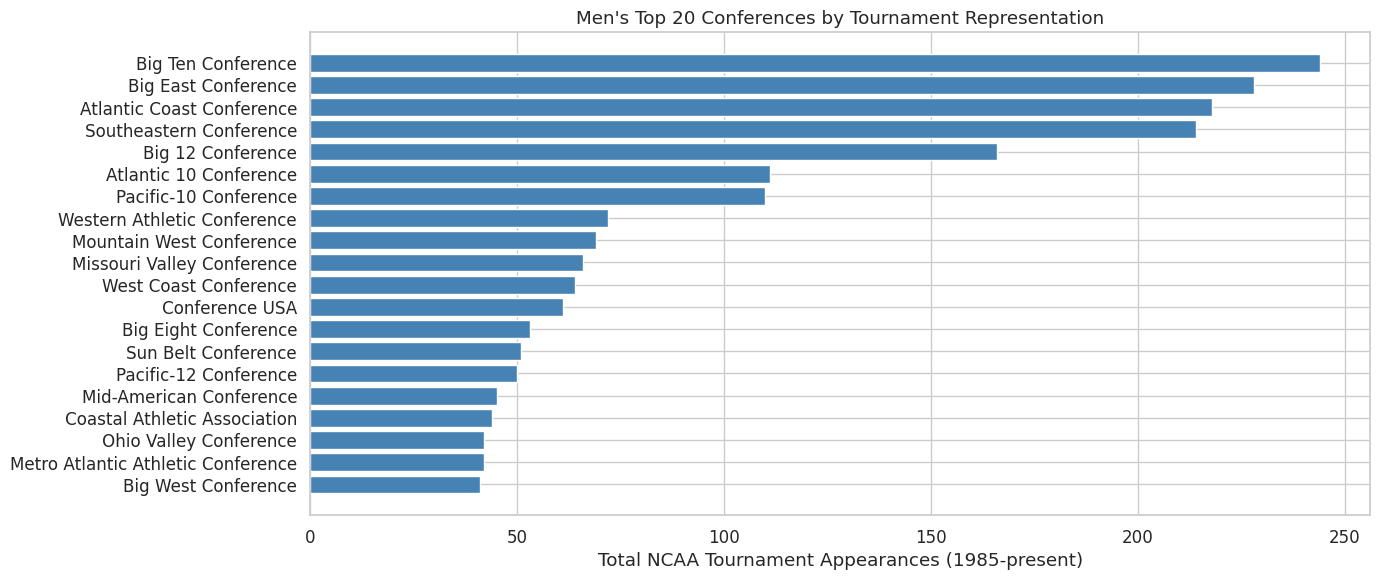

In [19]:
# Conference tournament appearances (top 15 conferences by NCAA tourney teams)
tourney_teams = m_seeds.merge(m_team_conf, on=["Season","TeamID"])
conf_counts = tourney_teams.groupby("ConfAbbrev").size().sort_values(ascending=False).head(20)
conf_counts = conf_counts.reset_index().merge(conferences, on="ConfAbbrev")
conf_counts.columns = ["ConfAbbrev", "TourneyTeams", "Conference"]

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(conf_counts["Conference"][::-1], conf_counts["TourneyTeams"][::-1], color="steelblue", edgecolor="white")
ax.set_xlabel("Total NCAA Tournament Appearances (1985-present)")
ax.set_title("Men's Top 20 Conferences by Tournament Representation")
plt.tight_layout()
plt.show()

In [20]:
# Coaching tenure — does experience matter?
coach_seasons = coaches.groupby(["TeamID", "CoachName"]).agg(
    Seasons=("Season", "nunique"),
    FirstSeason=("Season", "min"),
    LastSeason=("Season", "max")
).reset_index()

# Top 15 longest-serving coaches
top_coaches = coach_seasons.sort_values("Seasons", ascending=False).head(15)
top_coaches = top_coaches.merge(m_teams[["TeamID","TeamName"]], on="TeamID")
print("Top 15 longest-serving coaches:\n")
top_coaches[["CoachName","TeamName","Seasons","FirstSeason","LastSeason"]]

Top 15 longest-serving coaches:



,CoachName,TeamName,Seasons,FirstSeason,LastSeason
0,jim_boeheim,Syracuse,39,1985,2023
1,mike_krzyzewski,Duke,38,1985,2022
2,bob_mckillop,Davidson,33,1990,2022
3,tom_izzo,Michigan St,31,1996,2026
4,fang_mitchell,Coppin St,28,1987,2014
5,mark_few,Gonzaga,27,2000,2026
6,james_jones,Yale,27,2000,2026
7,dave_loos,Austin Peay,27,1991,2017
8,fran_o'hanlon,Lafayette,27,1996,2022
9,greg_kampe,Oakland,27,2000,2026


---
## 4. EDA — Women's Tournament Data

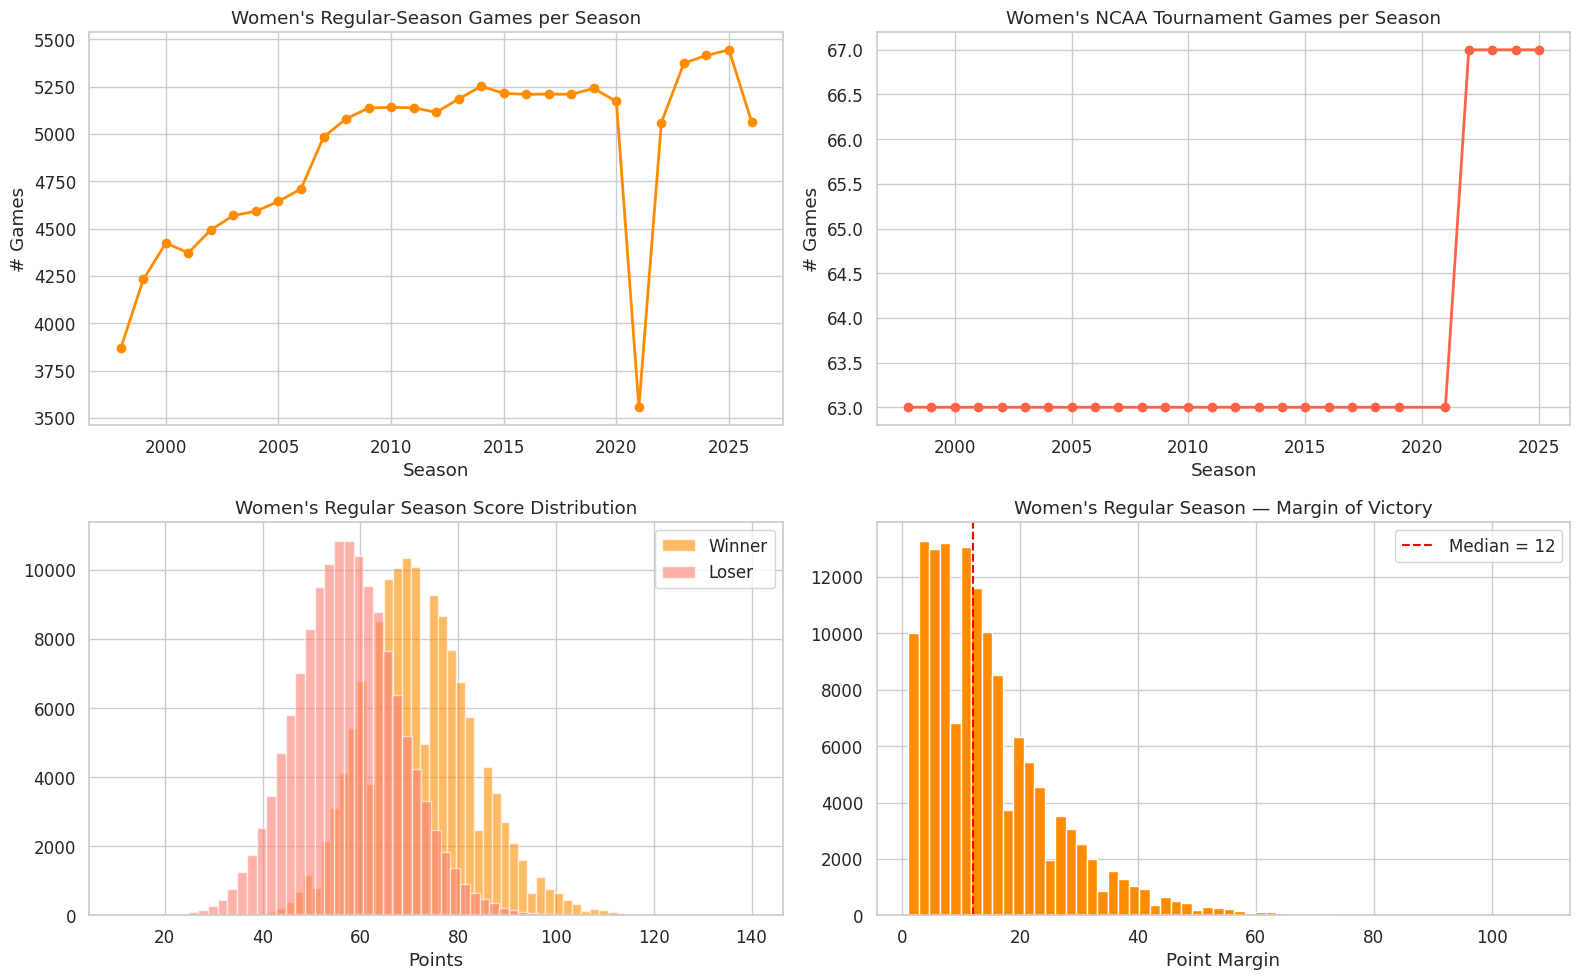

Women's avg winning score: 72.0 | avg losing score: 57.5
Women's avg margin: 14.4


In [21]:
# 4.1 Women's games per season & score distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

w_reg.groupby("Season").size().plot(ax=axes[0, 0], marker="o", linewidth=2, color="darkorange")
axes[0, 0].set_title("Women's Regular-Season Games per Season")
axes[0, 0].set_ylabel("# Games")

w_tourney.groupby("Season").size().plot(ax=axes[0, 1], marker="o", linewidth=2, color="tomato")
axes[0, 1].set_title("Women's NCAA Tournament Games per Season")
axes[0, 1].set_ylabel("# Games")

# Score distribution
axes[1, 0].hist(w_reg["WScore"], bins=60, alpha=0.6, label="Winner", color="darkorange")
axes[1, 0].hist(w_reg["LScore"], bins=60, alpha=0.6, label="Loser", color="salmon")
axes[1, 0].set_title("Women's Regular Season Score Distribution")
axes[1, 0].set_xlabel("Points")
axes[1, 0].legend()

# Margin
w_reg["Margin"] = w_reg["WScore"] - w_reg["LScore"]
axes[1, 1].hist(w_reg["Margin"], bins=60, color="darkorange", edgecolor="white")
axes[1, 1].set_title("Women's Regular Season — Margin of Victory")
axes[1, 1].set_xlabel("Point Margin")
axes[1, 1].axvline(w_reg["Margin"].median(), color="red", linestyle="--", label=f"Median = {w_reg['Margin'].median():.0f}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()
print(f"Women's avg winning score: {w_reg['WScore'].mean():.1f} | avg losing score: {w_reg['LScore'].mean():.1f}")
print(f"Women's avg margin: {w_reg['Margin'].mean():.1f}")

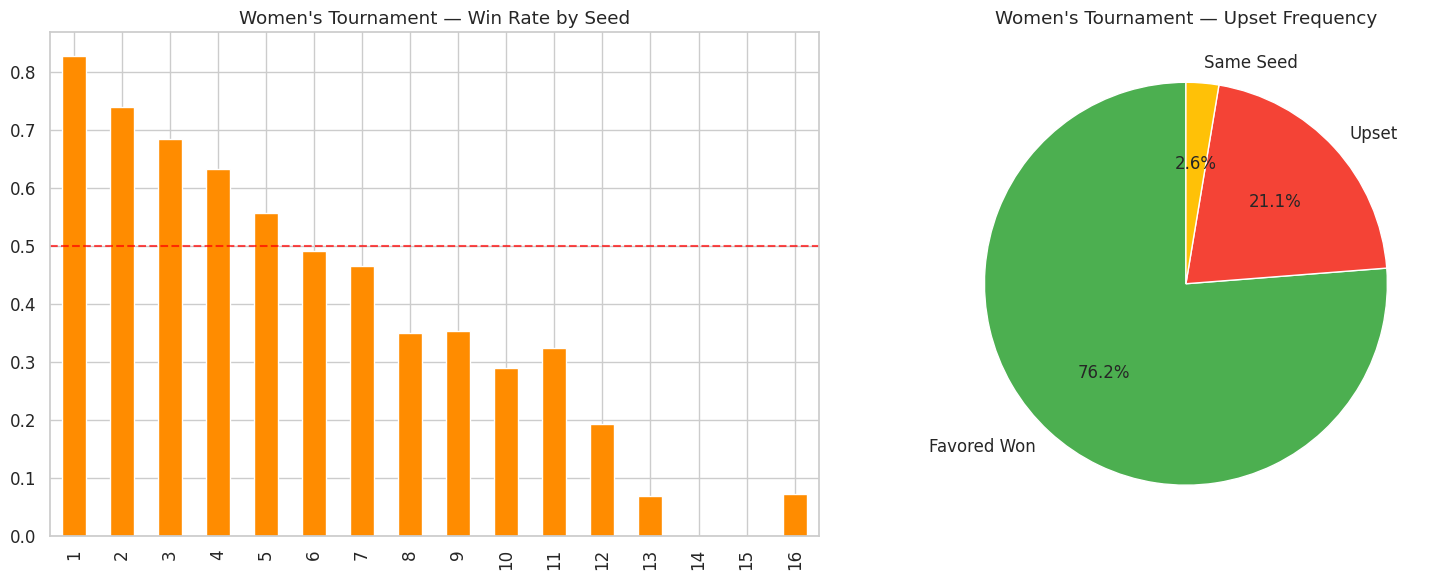

Women's upset rate: 21.7%
Men's upset rate:   28.4%
→ Women's tournament tends to be more predictable than men's


In [22]:
# 4.2 Women's Seed Analysis & Upset Rate
w_tour_seeds = (
    w_tourney
    .merge(w_seeds[["Season","TeamID","SeedNum"]], left_on=["Season","WTeamID"], right_on=["Season","TeamID"])
    .rename(columns={"SeedNum": "WSeed"}).drop(columns="TeamID")
    .merge(w_seeds[["Season","TeamID","SeedNum"]], left_on=["Season","LTeamID"], right_on=["Season","TeamID"])
    .rename(columns={"SeedNum": "LSeed"}).drop(columns="TeamID")
)

# Upset analysis
w_upsets = w_tour_seeds[w_tour_seeds["WSeed"] > w_tour_seeds["LSeed"]]
w_normal = w_tour_seeds[w_tour_seeds["WSeed"] < w_tour_seeds["LSeed"]]
w_equal  = w_tour_seeds[w_tour_seeds["WSeed"] == w_tour_seeds["LSeed"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Win rate by winner's seed (Women)
w_wseed_wins = w_tour_seeds.groupby("WSeed").size()
w_lseed_losses = w_tour_seeds.groupby("LSeed").size()
w_seed_total = w_wseed_wins.add(w_lseed_losses, fill_value=0)
w_seed_wr = (w_wseed_wins / w_seed_total).sort_index()
w_seed_wr.plot(kind="bar", ax=axes[0], color="darkorange", edgecolor="white")
axes[0].set_title("Women's Tournament — Win Rate by Seed")
axes[0].axhline(0.5, color="red", linestyle="--", alpha=0.7)

labels = ["Favored Won", "Upset", "Same Seed"]
sizes = [len(w_normal), len(w_upsets), len(w_equal)]
colors = ["#4CAF50", "#F44336", "#FFC107"]
axes[1].pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Women's Tournament — Upset Frequency")

plt.tight_layout()
plt.show()
print(f"Women's upset rate: {len(w_upsets) / (len(w_upsets)+len(w_normal)):.1%}")
print(f"Men's upset rate:   {len(upsets) / (len(upsets)+len(normal)):.1%}")
print(f"→ Women's tournament tends to be {'more' if len(w_upsets)/(len(w_upsets)+len(w_normal)) < len(upsets)/(len(upsets)+len(normal)) else 'less'} predictable than men's")

---
## 5. Feature Engineering

We build a comprehensive team-season feature matrix from multiple data sources. Features are computed per-team per-season, then merged into pairwise matchup features for prediction.

### Feature Categories:
1. **Basic Season Stats** — Win%, points scored/allowed, margin, home/away splits
2. **Advanced Box Score Metrics** — Effective FG%, turnover rate, offensive/defensive rebound rate, free throw rate (Four Factors)
3. **Strength of Schedule** — Opponent win rate, conference strength
4. **Ranking Features** — Massey ordinals (multiple systems)
5. **Tournament History** — Past seed, past tournament wins
6. **Coaching** — Coach tenure, coach tournament experience

In [23]:
# ============================================================
# 5.1 BASIC SEASON STATS (from compact results)
# ============================================================
# Unified function for both Men's and Women's data

def compute_basic_season_stats(reg_df):
    """Compute per-team per-season basic stats from compact results."""
    
    # --- Stats as the WINNING team ---
    w_stats = reg_df.groupby(["Season", "WTeamID"]).agg(
        Wins=("WScore", "count"),
        WPoints=("WScore", "sum"),
        WPointsAllowed=("LScore", "sum"),
        WHomeWins=("WLoc", lambda x: (x == "H").sum()),
        WAwayWins=("WLoc", lambda x: (x == "A").sum()),
        WNeutralWins=("WLoc", lambda x: (x == "N").sum()),
        WOTGames=("NumOT", lambda x: (x > 0).sum()),
    ).reset_index().rename(columns={"WTeamID": "TeamID"})
    
    # --- Stats as the LOSING team ---
    l_stats = reg_df.groupby(["Season", "LTeamID"]).agg(
        Losses=("LScore", "count"),
        LPoints=("LScore", "sum"),
        LPointsAllowed=("WScore", "sum"),
        # When the loser's location — flip WLoc: H→A, A→H for the loser
        LHomeLosses=("WLoc", lambda x: (x == "A").sum()),    # if winner is Away, loser is Home
        LAwayLosses=("WLoc", lambda x: (x == "H").sum()),    # if winner is Home, loser is Away
        LNeutralLosses=("WLoc", lambda x: (x == "N").sum()),
    ).reset_index().rename(columns={"LTeamID": "TeamID"})
    
    # Merge wins and losses
    stats = w_stats.merge(l_stats, on=["Season", "TeamID"], how="outer").fillna(0)
    
    # Derived features
    stats["Games"]      = stats["Wins"] + stats["Losses"]
    stats["WinPct"]     = stats["Wins"] / stats["Games"]
    stats["PointsFor"]  = stats["WPoints"] + stats["LPoints"]
    stats["PointsAga"]  = stats["WPointsAllowed"] + stats["LPointsAllowed"]
    stats["PPG"]        = stats["PointsFor"] / stats["Games"]
    stats["PAPG"]       = stats["PointsAga"] / stats["Games"]
    stats["AvgMargin"]  = stats["PPG"] - stats["PAPG"]
    stats["HomeWinPct"] = stats["WHomeWins"] / (stats["WHomeWins"] + stats["LHomeLosses"]).replace(0, 1)
    stats["AwayWinPct"] = stats["WAwayWins"] / (stats["WAwayWins"] + stats["LAwayLosses"]).replace(0, 1)
    
    # Keep clean columns
    keep_cols = ["Season", "TeamID", "Wins", "Losses", "Games", "WinPct",
                 "PPG", "PAPG", "AvgMargin", "HomeWinPct", "AwayWinPct"]
    return stats[keep_cols]

m_basic = compute_basic_season_stats(m_reg)
w_basic = compute_basic_season_stats(w_reg)

print(f"Men's basic stats: {m_basic.shape}")
print(f"Women's basic stats: {w_basic.shape}")
m_basic.head()

Men's basic stats: (13753, 11)
Women's basic stats: (9851, 11)


,Season,TeamID,Wins,Losses,Games,WinPct,PPG,PAPG,AvgMargin,HomeWinPct,AwayWinPct
0,1985,1102,5.0,19.0,24.0,0.208333,63.083333,68.875000,-5.791667,0.200000,0.250000
1,1985,1103,9.0,14.0,23.0,0.391304,61.043478,64.086957,-3.043478,0.538462,0.200000
2,1985,1104,21.0,9.0,30.0,0.700000,68.500000,60.700000,7.800000,0.937500,0.454545
3,1985,1106,10.0,14.0,24.0,0.416667,71.625000,75.416667,-3.791667,0.888889,0.090909
4,1985,1108,19.0,6.0,25.0,0.760000,83.000000,75.040000,7.960000,0.888889,0.666667


In [24]:
# ============================================================
# 5.2 ADVANCED BOX SCORE METRICS (Four Factors + extras)
# ============================================================

def compute_advanced_stats(det_df):
    """Compute per-team per-season advanced stats from detailed results.
    
    Dean Oliver's Four Factors:
    1. Effective FG% = (FGM + 0.5 * FGM3) / FGA
    2. Turnover Rate = TO / (FGA + 0.44 * FTA + TO)
    3. Offensive Rebound % = OR / (OR + Opp_DR)
    4. Free Throw Rate = FTM / FGA
    
    Plus: Assist Rate, Steal Rate, Block Rate
    """
    
    # --- As the winning team ---
    w = det_df.copy()
    w_agg = w.groupby(["Season", "WTeamID"]).agg(
        W_FGM=("WFGM","sum"), W_FGA=("WFGA","sum"),
        W_FGM3=("WFGM3","sum"), W_FGA3=("WFGA3","sum"),
        W_FTM=("WFTM","sum"), W_FTA=("WFTA","sum"),
        W_OR=("WOR","sum"), W_DR=("WDR","sum"),
        W_Ast=("WAst","sum"), W_TO=("WTO","sum"),
        W_Stl=("WStl","sum"), W_Blk=("WBlk","sum"),
        W_PF=("WPF","sum"),
        # Opponent stats (losing team stats when this team won)
        W_Opp_OR=("LOR","sum"), W_Opp_DR=("LDR","sum"),
        W_Opp_FGA=("LFGA","sum"), W_Opp_FGM=("LFGM","sum"),
        W_Opp_TO=("LTO","sum"),
        W_Games=("WFGM","count"),
    ).reset_index().rename(columns={"WTeamID": "TeamID"})

    # --- As the losing team ---
    l_agg = w.groupby(["Season", "LTeamID"]).agg(
        L_FGM=("LFGM","sum"), L_FGA=("LFGA","sum"),
        L_FGM3=("LFGM3","sum"), L_FGA3=("LFGA3","sum"),
        L_FTM=("LFTM","sum"), L_FTA=("LFTA","sum"),
        L_OR=("LOR","sum"), L_DR=("LDR","sum"),
        L_Ast=("LAst","sum"), L_TO=("LTO","sum"),
        L_Stl=("LStl","sum"), L_Blk=("LBlk","sum"),
        L_PF=("LPF","sum"),
        # Opponent stats (winning team stats when this team lost)
        L_Opp_OR=("WOR","sum"), L_Opp_DR=("WDR","sum"),
        L_Opp_FGA=("WFGA","sum"), L_Opp_FGM=("WFGM","sum"),
        L_Opp_TO=("WTO","sum"),
        L_Games=("LFGM","count"),
    ).reset_index().rename(columns={"LTeamID": "TeamID"})
    
    # Merge and sum
    stats = w_agg.merge(l_agg, on=["Season","TeamID"], how="outer").fillna(0)
    
    # Totals
    stats["FGM"]  = stats["W_FGM"]  + stats["L_FGM"]
    stats["FGA"]  = stats["W_FGA"]  + stats["L_FGA"]
    stats["FGM3"] = stats["W_FGM3"] + stats["L_FGM3"]
    stats["FGA3"] = stats["W_FGA3"] + stats["L_FGA3"]
    stats["FTM"]  = stats["W_FTM"]  + stats["L_FTM"]
    stats["FTA"]  = stats["W_FTA"]  + stats["L_FTA"]
    stats["OR"]   = stats["W_OR"]   + stats["L_OR"]
    stats["DR"]   = stats["W_DR"]   + stats["L_DR"]
    stats["Ast"]  = stats["W_Ast"]  + stats["L_Ast"]
    stats["TO"]   = stats["W_TO"]   + stats["L_TO"]
    stats["Stl"]  = stats["W_Stl"]  + stats["L_Stl"]
    stats["Blk"]  = stats["W_Blk"]  + stats["L_Blk"]
    stats["PF"]   = stats["W_PF"]   + stats["L_PF"]
    stats["Opp_OR"]  = stats["W_Opp_OR"]  + stats["L_Opp_OR"]
    stats["Opp_DR"]  = stats["W_Opp_DR"]  + stats["L_Opp_DR"]
    stats["Opp_FGA"] = stats["W_Opp_FGA"] + stats["L_Opp_FGA"]
    stats["Opp_FGM"] = stats["W_Opp_FGM"] + stats["L_Opp_FGM"]
    stats["Opp_TO"]  = stats["W_Opp_TO"]  + stats["L_Opp_TO"]
    stats["Games"]   = stats["W_Games"]   + stats["L_Games"]
    
    # ---- Four Factors (Offense) ----
    stats["eFGPct"]   = (stats["FGM"] + 0.5 * stats["FGM3"]) / stats["FGA"].replace(0,1)
    stats["TORate"]   = stats["TO"] / (stats["FGA"] + 0.44 * stats["FTA"] + stats["TO"]).replace(0,1)
    stats["ORPct"]    = stats["OR"] / (stats["OR"] + stats["Opp_DR"]).replace(0,1)
    stats["FTRate"]   = stats["FTM"] / stats["FGA"].replace(0,1)
    
    # ---- Four Factors (Defense) ----
    stats["Opp_eFGPct"] = (stats["Opp_FGM"] + 0.5 * (stats["Opp_FGM"] - (stats["Opp_FGM"] - stats["FGM3"]))) / stats["Opp_FGA"].replace(0,1)  # approx
    stats["Opp_TORate"]  = stats["Opp_TO"] / (stats["Opp_FGA"] + 0.44 * stats["FTA"] + stats["Opp_TO"]).replace(0,1)
    stats["DRPct"]       = stats["DR"] / (stats["DR"] + stats["Opp_OR"]).replace(0,1)
    
    # ---- Per-game extras ----
    stats["AstPerGame"]  = stats["Ast"] / stats["Games"].replace(0,1)
    stats["StlPerGame"]  = stats["Stl"] / stats["Games"].replace(0,1)
    stats["BlkPerGame"]  = stats["Blk"] / stats["Games"].replace(0,1)
    stats["PFPerGame"]   = stats["PF"]  / stats["Games"].replace(0,1)
    stats["TOPerGame"]   = stats["TO"]  / stats["Games"].replace(0,1)
    stats["FGPct"]       = stats["FGM"] / stats["FGA"].replace(0,1)
    stats["FG3Pct"]      = stats["FGM3"] / stats["FGA3"].replace(0,1)
    stats["FTPct"]       = stats["FTM"] / stats["FTA"].replace(0,1)
    stats["TRB"]         = (stats["OR"] + stats["DR"]) / stats["Games"].replace(0,1)  # total rebounds per game
    
    keep_cols = ["Season", "TeamID", "eFGPct", "TORate", "ORPct", "FTRate", "DRPct",
                 "Opp_eFGPct", "Opp_TORate", "AstPerGame", "StlPerGame", "BlkPerGame",
                 "PFPerGame", "TOPerGame", "FGPct", "FG3Pct", "FTPct", "TRB"]
    return stats[keep_cols]

m_adv = compute_advanced_stats(m_reg_det)
w_adv = compute_advanced_stats(w_reg_det)

print(f"Men's advanced stats: {m_adv.shape} (seasons {m_adv['Season'].min()}-{m_adv['Season'].max()})")
print(f"Women's advanced stats: {w_adv.shape} (seasons {w_adv['Season'].min()}-{w_adv['Season'].max()})")
m_adv.head()

Men's advanced stats: (8346, 18) (seasons 2003-2026)
Women's advanced stats: (5965, 18) (seasons 2010-2026)


,Season,TeamID,eFGPct,TORate,ORPct,FTRate,DRPct,Opp_eFGPct,Opp_TORate,AstPerGame,StlPerGame,BlkPerGame,PFPerGame,TOPerGame,FGPct,FG3Pct,FTPct,TRB
0,2003,1102,0.579443,0.194557,0.171806,0.280072,0.636486,0.546717,0.206044,13.000000,5.964286,1.785714,18.750000,11.428571,0.481149,0.375643,0.651357,21.000000
1,2003,1103,0.534814,0.158154,0.307334,0.340849,0.623407,0.535088,0.183176,15.222222,7.259259,2.333333,19.851852,12.629630,0.486074,0.338710,0.736390,29.703704
2,2003,1104,0.475953,0.166753,0.374753,0.259838,0.687179,0.476190,0.176376,12.107143,6.607143,3.785714,18.035714,13.285714,0.420362,0.320144,0.709898,37.500000
3,2003,1105,0.457241,0.207538,0.338476,0.250312,0.636653,0.522179,0.215236,14.538462,9.307692,2.076923,20.230769,18.653846,0.395755,0.364815,0.705986,36.615385
4,2003,1106,0.479005,0.214109,0.354639,0.192506,0.678173,0.463880,0.199072,11.678571,8.357143,3.142857,18.178571,17.035714,0.423773,0.346154,0.646421,36.142857


In [25]:
# ============================================================
# 5.3 STRENGTH OF SCHEDULE
# ============================================================

def compute_sos(reg_df, basic_df):
    """Compute strength of schedule: average opponent win percentage."""
    
    # Build opponent list per team-season (from both W and L perspectives)
    w_opps = reg_df[["Season","WTeamID","LTeamID"]].rename(columns={"WTeamID":"TeamID","LTeamID":"OppID"})
    l_opps = reg_df[["Season","LTeamID","WTeamID"]].rename(columns={"LTeamID":"TeamID","WTeamID":"OppID"})
    all_opps = pd.concat([w_opps, l_opps], ignore_index=True)
    
    # Merge opponent win %
    all_opps = all_opps.merge(basic_df[["Season","TeamID","WinPct"]], 
                               left_on=["Season","OppID"], right_on=["Season","TeamID"],
                               suffixes=("","_opp")).drop(columns="TeamID_opp")
    
    sos = all_opps.groupby(["Season","TeamID"])["WinPct"].mean().reset_index()
    sos.columns = ["Season", "TeamID", "SOS"]
    return sos

m_sos = compute_sos(m_reg, m_basic)
w_sos = compute_sos(w_reg, w_basic)

print(f"Men's SOS: {m_sos.shape}")
m_sos.head()

Men's SOS: (13753, 3)


,Season,TeamID,SOS
0,1985,1102,0.500130
1,1985,1103,0.474244
2,1985,1104,0.526081
3,1985,1106,0.462600
4,1985,1108,0.439307


In [26]:
# ============================================================
# 5.4 RANKING FEATURES (Massey Ordinals — Men only)
# ============================================================

# Use final pre-tournament rankings from key systems
# We'll create: mean rank across all systems, best rank, and specific system ranks
massey_final = massey[massey["RankingDayNum"] == 133].copy()

# Aggregate across all systems per team-season
rank_agg = massey_final.groupby(["Season","TeamID"])["OrdinalRank"].agg(
    MeanRank="mean",
    MedianRank="median",
    BestRank="min",
    WorstRank="max",
    StdRank="std",
    NumSystems="count"
).reset_index()

# Also grab specific top systems as individual features
top_systems = ["POM", "SAG", "MOR", "DOL", "COL"]  # well-known systems
for sys_name in top_systems:
    sys_df = massey_final[massey_final["SystemName"] == sys_name][["Season","TeamID","OrdinalRank"]]
    sys_df = sys_df.rename(columns={"OrdinalRank": f"Rank_{sys_name}"})
    rank_agg = rank_agg.merge(sys_df, on=["Season","TeamID"], how="left")

m_ranks = rank_agg.copy()
print(f"Men's ranking features: {m_ranks.shape}")
print(f"Columns: {m_ranks.columns.tolist()}")
m_ranks.head()

Men's ranking features: (7627, 13)
Columns: ['Season', 'TeamID', 'MeanRank', 'MedianRank', 'BestRank', 'WorstRank', 'StdRank', 'NumSystems', 'Rank_POM', 'Rank_SAG', 'Rank_MOR', 'Rank_DOL', 'Rank_COL']


,Season,TeamID,MeanRank,MedianRank,BestRank,WorstRank,StdRank,NumSystems,Rank_POM,Rank_SAG,Rank_MOR,Rank_DOL,Rank_COL
0,2003,1102,156.03125,156.0,97,198,17.102130,32,160.0,149.0,132,175.0,162.0
1,2003,1103,168.00000,170.5,128,194,12.559536,32,163.0,172.0,139,174.0,172.0
2,2003,1104,38.03125,37.0,26,60,6.794136,32,33.0,37.0,26,39.0,43.0
3,2003,1105,308.96875,310.0,289,315,5.877702,32,307.0,312.0,309,315.0,310.0
4,2003,1106,262.68750,265.5,198,305,21.178866,32,263.0,268.0,294,266.0,256.0


In [27]:
# ============================================================
# 5.5 TOURNAMENT HISTORY & SEED FEATURES
# ============================================================

def compute_seed_features(seeds_df):
    """Parse seed number as a feature."""
    df = seeds_df.copy()
    df["SeedNum"] = df["Seed"].apply(lambda x: int(x[1:3]))
    df["SeedRegion"] = df["Seed"].str[0]
    return df[["Season","TeamID","SeedNum","SeedRegion"]]

m_seed_feat = compute_seed_features(m_seeds)
w_seed_feat = compute_seed_features(w_seeds)

# Historical tournament performance: cumulative wins in past tournaments
def compute_tourney_history(tourney_df):
    """Compute each team's historical tournament win count up to (not including) each season."""
    # Count wins per season
    wins_per_season = tourney_df.groupby(["Season","WTeamID"]).size().reset_index(name="TourneyWins")
    wins_per_season = wins_per_season.rename(columns={"WTeamID": "TeamID"})
    
    # Cumulative sum of past tourney wins (shifted by 1 season)
    wins_per_season = wins_per_season.sort_values(["TeamID","Season"])
    wins_per_season["CumTourneyWins"] = wins_per_season.groupby("TeamID")["TourneyWins"].cumsum().shift(1)
    wins_per_season["CumTourneyWins"] = wins_per_season.groupby("TeamID")["CumTourneyWins"].ffill().fillna(0)
    
    return wins_per_season[["Season","TeamID","CumTourneyWins"]]

m_tour_hist = compute_tourney_history(m_tourney)
w_tour_hist = compute_tourney_history(w_tourney)

print(f"Men's seed features: {m_seed_feat.shape}")
print(f"Men's tourney history: {m_tour_hist.shape}")
m_seed_feat.head()

Men's seed features: (2626, 4)
Men's tourney history: (1333, 3)


,Season,TeamID,SeedNum,SeedRegion
0,1985,1207,1,W
1,1985,1210,2,W
2,1985,1228,3,W
3,1985,1260,4,W
4,1985,1374,5,W


In [28]:
# ============================================================
# 5.6 COACHING FEATURES (Men only)
# ============================================================

# Coach tenure at current team and total D1 experience
coach_tenure = coaches.copy()
coach_tenure = coach_tenure.sort_values(["CoachName","Season"])

# Seasons coached at current team (cumulative up to this season)
coach_at_team = coach_tenure.groupby(["TeamID","CoachName"]).agg(
    CoachStart=("Season","min"),
    CoachSeasons=("Season","nunique")
).reset_index()

# For each season, figure out who the coach is and how long they've been there
coach_per_season = coach_tenure[coach_tenure["LastDayNum"] == 154].copy()  # full-season coaches
coach_per_season = coach_per_season.sort_values(["TeamID","CoachName","Season"])
coach_per_season["TenureAtTeam"] = coach_per_season.groupby(["TeamID","CoachName"]).cumcount() + 1

# Total D1 coaching experience (across all teams)
coach_per_season["TotalExperience"] = coach_per_season.groupby("CoachName").cumcount() + 1

# Tournament coaching experience
tourney_coaches = m_tourney[["Season","WTeamID"]].rename(columns={"WTeamID":"TeamID"}).drop_duplicates()
tourney_coaches2 = m_tourney[["Season","LTeamID"]].rename(columns={"LTeamID":"TeamID"}).drop_duplicates()
tourney_coach_seasons = pd.concat([tourney_coaches, tourney_coaches2]).drop_duplicates()
tourney_coach_merged = tourney_coach_seasons.merge(
    coach_per_season[["Season","TeamID","CoachName"]], on=["Season","TeamID"], how="inner"
)
coach_tourney_exp = tourney_coach_merged.groupby("CoachName").cumcount()
tourney_coach_merged["CoachTourneyExp"] = coach_tourney_exp

m_coach_feat = coach_per_season[["Season","TeamID","CoachName","TenureAtTeam","TotalExperience"]].copy()
m_coach_feat = m_coach_feat.merge(
    tourney_coach_merged[["Season","TeamID","CoachTourneyExp"]],
    on=["Season","TeamID"], how="left"
).fillna({"CoachTourneyExp": 0})

print(f"Men's coach features: {m_coach_feat.shape}")
m_coach_feat.head()

Men's coach features: (13398, 6)


,Season,TeamID,CoachName,TenureAtTeam,TotalExperience,CoachTourneyExp
0,2022,1101,brette_tanner,1,1,0.0
1,2023,1101,brette_tanner,2,2,0.0
2,2024,1101,brette_tanner,3,3,0.0
3,2025,1101,brette_tanner,4,4,0.0
4,2014,1101,joe_golding,1,1,0.0


In [29]:
# ============================================================
# 5.7 CONFERENCE STRENGTH FEATURES
# ============================================================

def compute_conf_strength(team_conf_df, basic_df):
    """Average win% and scoring of teams in the same conference."""
    merged = team_conf_df.merge(basic_df, on=["Season","TeamID"], how="inner")
    conf_strength = merged.groupby(["Season","ConfAbbrev"]).agg(
        ConfAvgWinPct=("WinPct", "mean"),
        ConfAvgPPG=("PPG", "mean"),
        ConfAvgMargin=("AvgMargin", "mean"),
        ConfTeamCount=("TeamID", "count"),
    ).reset_index()
    
    # Merge back onto teams
    result = team_conf_df.merge(conf_strength, on=["Season","ConfAbbrev"], how="left")
    return result[["Season","TeamID","ConfAbbrev","ConfAvgWinPct","ConfAvgPPG","ConfAvgMargin","ConfTeamCount"]]

m_conf_str = compute_conf_strength(m_team_conf, m_basic)
w_conf_str = compute_conf_strength(w_team_conf, w_basic)

print(f"Men's conference strength: {m_conf_str.shape}")
m_conf_str.head()

Men's conference strength: (13753, 7)


,Season,TeamID,ConfAbbrev,ConfAvgWinPct,ConfAvgPPG,ConfAvgMargin,ConfTeamCount
0,1985,1102,wac,0.513876,70.510235,0.935614,9
1,1985,1103,ovc,0.459255,65.311017,-1.609511,8
2,1985,1104,sec,0.557997,69.614669,2.359805,10
3,1985,1106,swac,0.434973,73.172406,-1.379136,8
4,1985,1108,swac,0.434973,73.172406,-1.379136,8


In [30]:
# ============================================================
# 5.8 LAST N GAMES MOMENTUM (Recent form — last 10 games)
# ============================================================

def compute_recent_form(reg_df, n=10):
    """Win% and scoring in the last N regular season games per team-season."""
    
    # Get last N games for each team (combining W and L perspectives)
    w_games = reg_df[["Season","DayNum","WTeamID","WScore","LScore"]].rename(
        columns={"WTeamID":"TeamID","WScore":"PtsFor","LScore":"PtsAga"})
    w_games["Win"] = 1
    
    l_games = reg_df[["Season","DayNum","LTeamID","LScore","WScore"]].rename(
        columns={"LTeamID":"TeamID","LScore":"PtsFor","WScore":"PtsAga"})
    l_games["Win"] = 0
    
    all_games = pd.concat([w_games, l_games]).sort_values(["Season","TeamID","DayNum"])
    
    # Last N games per team per season
    last_n = all_games.groupby(["Season","TeamID"]).tail(n)
    
    recent = last_n.groupby(["Season","TeamID"]).agg(
        Last10WinPct=("Win","mean"),
        Last10PPG=("PtsFor","mean"),
        Last10PAPG=("PtsAga","mean"),
    ).reset_index()
    recent["Last10Margin"] = recent["Last10PPG"] - recent["Last10PAPG"]
    
    return recent

m_recent = compute_recent_form(m_reg, n=10)
w_recent = compute_recent_form(w_reg, n=10)

print(f"Men's recent form: {m_recent.shape}")
m_recent.head()

Men's recent form: (13753, 6)


,Season,TeamID,Last10WinPct,Last10PPG,Last10PAPG,Last10Margin
0,1985,1102,0.3,60.9,63.5,-2.6
1,1985,1103,0.4,62.0,66.3,-4.3
2,1985,1104,0.7,66.0,56.4,9.6
3,1985,1106,0.6,71.8,74.1,-2.3
4,1985,1108,0.9,79.9,72.5,7.4


In [31]:
# ============================================================
# 5.9 ASSEMBLE TEAM-SEASON FEATURE MATRIX
# ============================================================

def assemble_features(basic, adv, sos, conf_str, recent, ranks=None, coach=None, seed=None, tour_hist=None, gender="M"):
    """Merge all feature tables into a single team-season matrix."""
    feat = basic.copy()
    feat = feat.merge(adv, on=["Season","TeamID"], how="left")
    feat = feat.merge(sos, on=["Season","TeamID"], how="left")
    feat = feat.merge(conf_str.drop(columns="ConfAbbrev"), on=["Season","TeamID"], how="left")
    feat = feat.merge(recent, on=["Season","TeamID"], how="left")
    
    if ranks is not None:
        feat = feat.merge(ranks, on=["Season","TeamID"], how="left")
    if coach is not None:
        feat = feat.merge(coach.drop(columns="CoachName", errors="ignore"), on=["Season","TeamID"], how="left")
    if seed is not None:
        feat = feat.merge(seed, on=["Season","TeamID"], how="left")
    if tour_hist is not None:
        feat = feat.merge(tour_hist, on=["Season","TeamID"], how="left")
    
    feat["Gender"] = gender
    return feat

# Men's features
m_features = assemble_features(
    m_basic, m_adv, m_sos, m_conf_str, m_recent,
    ranks=m_ranks, coach=m_coach_feat, seed=m_seed_feat, tour_hist=m_tour_hist, gender="M"
)

# Women's features (no Massey rankings or coaching data available)
w_features = assemble_features(
    w_basic, w_adv, w_sos, w_conf_str, w_recent,
    seed=w_seed_feat, tour_hist=w_tour_hist, gender="W"
)

print(f"Men's feature matrix:   {m_features.shape} — {m_features.columns.tolist()}")
print(f"\nWomen's feature matrix: {w_features.shape} — {w_features.columns.tolist()}")
print(f"\nMissing values (Men):\n{m_features.isnull().sum()[m_features.isnull().sum() > 0]}")
print(f"\nMissing values (Women):\n{w_features.isnull().sum()[w_features.isnull().sum() > 0]}")

Men's feature matrix:   (13753, 54) — ['Season', 'TeamID', 'Wins', 'Losses', 'Games', 'WinPct', 'PPG', 'PAPG', 'AvgMargin', 'HomeWinPct', 'AwayWinPct', 'eFGPct', 'TORate', 'ORPct', 'FTRate', 'DRPct', 'Opp_eFGPct', 'Opp_TORate', 'AstPerGame', 'StlPerGame', 'BlkPerGame', 'PFPerGame', 'TOPerGame', 'FGPct', 'FG3Pct', 'FTPct', 'TRB', 'SOS', 'ConfAvgWinPct', 'ConfAvgPPG', 'ConfAvgMargin', 'ConfTeamCount', 'Last10WinPct', 'Last10PPG', 'Last10PAPG', 'Last10Margin', 'MeanRank', 'MedianRank', 'BestRank', 'WorstRank', 'StdRank', 'NumSystems', 'Rank_POM', 'Rank_SAG', 'Rank_MOR', 'Rank_DOL', 'Rank_COL', 'TenureAtTeam', 'TotalExperience', 'CoachTourneyExp', 'SeedNum', 'SeedRegion', 'CumTourneyWins', 'Gender']

Women's feature matrix: (9851, 40) — ['Season', 'TeamID', 'Wins', 'Losses', 'Games', 'WinPct', 'PPG', 'PAPG', 'AvgMargin', 'HomeWinPct', 'AwayWinPct', 'eFGPct', 'TORate', 'ORPct', 'FTRate', 'DRPct', 'Opp_eFGPct', 'Opp_TORate', 'AstPerGame', 'StlPerGame', 'BlkPerGame', 'PFPerGame', 'TOPerGame',

In [32]:
# ============================================================
# 5.10 BUILD PAIRWISE MATCHUP FEATURES (for training)
# ============================================================

def build_matchup_features(tourney_df, feature_df, drop_cols=None):
    """Create pairwise matchup training data from tournament results.
    
    For each game, we create a row with:
    - Team1 features (lower TeamID) and Team2 features (higher TeamID)
    - Target: 1 if Team1 (lower ID) won, 0 otherwise
    
    Feature differences (Team1 - Team2) are computed for modeling.
    """
    if drop_cols is None:
        drop_cols = ["Gender", "SeedRegion"]
    
    games = tourney_df.copy()
    games["Team1"] = games[["WTeamID","LTeamID"]].min(axis=1)
    games["Team2"] = games[["WTeamID","LTeamID"]].max(axis=1)
    games["Target"] = (games["WTeamID"] == games["Team1"]).astype(int)
    
    # Get feature columns (everything except Season, TeamID, and drop_cols)
    feat_cols = [c for c in feature_df.columns if c not in ["Season","TeamID"] + (drop_cols or [])]
    
    # Merge features for Team1
    t1_feat = feature_df.drop(columns=[c for c in drop_cols if c in feature_df.columns], errors="ignore")
    t2_feat = t1_feat.copy()
    
    merged = games[["Season","Team1","Team2","Target"]].merge(
        t1_feat, left_on=["Season","Team1"], right_on=["Season","TeamID"], how="left"
    ).drop(columns="TeamID")
    
    merged = merged.merge(
        t2_feat, left_on=["Season","Team2"], right_on=["Season","TeamID"],
        how="left", suffixes=("_T1","_T2")
    ).drop(columns="TeamID")
    
    # Compute differences (Team1 - Team2) for each feature
    for col in feat_cols:
        if f"{col}_T1" in merged.columns and f"{col}_T2" in merged.columns:
            merged[f"Diff_{col}"] = merged[f"{col}_T1"] - merged[f"{col}_T2"]
    
    return merged

m_matchups = build_matchup_features(m_tourney, m_features)
w_matchups = build_matchup_features(w_tourney, w_features)

print(f"Men's matchups for training: {m_matchups.shape}")
print(f"Women's matchups for training: {w_matchups.shape}")
print(f"\nTarget distribution (Men):\n{m_matchups['Target'].value_counts()}")
print(f"\nSample diff features: {[c for c in m_matchups.columns if c.startswith('Diff_')][:10]}")
m_matchups.head(3)

Men's matchups for training: (2585, 154)
Women's matchups for training: (1717, 112)

Target distribution (Men):
Target
1    1323
0    1262
Name: count, dtype: int64

Sample diff features: ['Diff_Wins', 'Diff_Losses', 'Diff_Games', 'Diff_WinPct', 'Diff_PPG', 'Diff_PAPG', 'Diff_AvgMargin', 'Diff_HomeWinPct', 'Diff_AwayWinPct', 'Diff_eFGPct']


,Season,Team1,Team2,Target,Wins_T1,Losses_T1,Games_T1,WinPct_T1,PPG_T1,PAPG_T1,AvgMargin_T1,HomeWinPct_T1,AwayWinPct_T1,eFGPct_T1,TORate_T1,ORPct_T1,FTRate_T1,DRPct_T1,Opp_eFGPct_T1,Opp_TORate_T1,AstPerGame_T1,StlPerGame_T1,BlkPerGame_T1,PFPerGame_T1,TOPerGame_T1,...,Diff_SOS,Diff_ConfAvgWinPct,Diff_ConfAvgPPG,Diff_ConfAvgMargin,Diff_ConfTeamCount,Diff_Last10WinPct,Diff_Last10PPG,Diff_Last10PAPG,Diff_Last10Margin,Diff_MeanRank,Diff_MedianRank,Diff_BestRank,Diff_WorstRank,Diff_StdRank,Diff_NumSystems,Diff_Rank_POM,Diff_Rank_SAG,Diff_Rank_MOR,Diff_Rank_DOL,Diff_Rank_COL,Diff_TenureAtTeam,Diff_TotalExperience,Diff_CoachTourneyExp,Diff_SeedNum,Diff_CumTourneyWins
0,1985,1116,1234,1,21.0,12.0,33.0,0.636364,65.333333,61.696970,3.636364,0.909091,0.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.020862,-0.050158,0.171509,-1.747711,-1,0.2,7.1,-0.9,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,-1.0,1.0,NaN
1,1985,1120,1345,1,18.0,11.0,29.0,0.620690,70.344828,66.655172,3.689655,0.666667,0.454545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.002403,-0.037402,-0.094618,-0.954508,0,-0.1,0.0,-1.8,1.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,-11.0,5.0,NaN
2,1985,1207,1250,1,25.0,2.0,27.0,0.925926,75.740741,60.074074,15.666667,0.923077,0.857143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.131907,0.194303,4.548405,7.232607,1,0.5,15.1,-6.3,21.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,-15.0,NaN


---
## 6. Feature Selection

Analyze the engineered features to determine which are most predictive:
1. **Correlation with target** — Pearson & Spearman correlations
2. **Mutual Information** — Non-linear dependency measure
3. **Variance Threshold** — Remove near-zero variance features
4. **Multicollinearity** — Detect highly correlated feature pairs

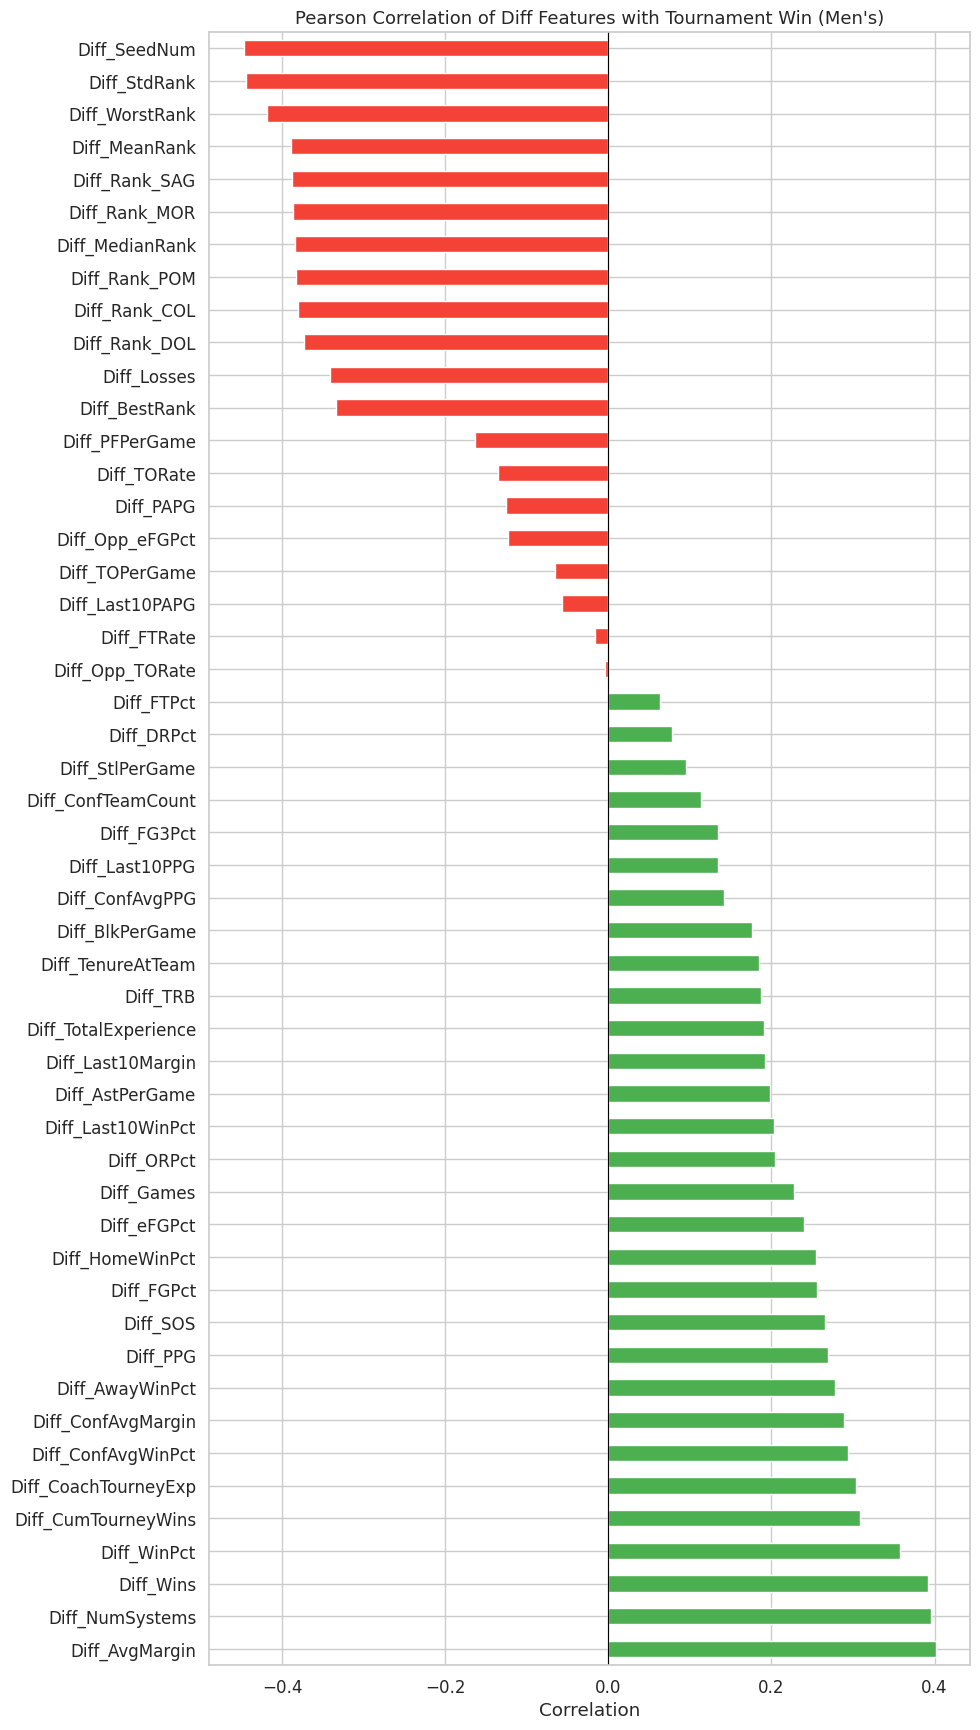

Top 10 most correlated features:
Diff_SeedNum       0.446695
Diff_StdRank       0.444093
Diff_WorstRank     0.418828
Diff_AvgMargin     0.401459
Diff_NumSystems    0.395472
Diff_Wins          0.391744
Diff_MeanRank      0.388762
Diff_Rank_SAG      0.387234
Diff_Rank_MOR      0.386307
Diff_MedianRank    0.384619
dtype: float64


In [33]:
# ============================================================
# 6.1 CORRELATION WITH TARGET (Diff features)
# ============================================================
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

# Focus on diff features for the Men's matchup data
diff_cols = [c for c in m_matchups.columns if c.startswith("Diff_")]
analysis_df = m_matchups[diff_cols + ["Target"]].dropna()

# Pearson correlation with target
correlations = analysis_df[diff_cols].corrwith(analysis_df["Target"]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(8, len(correlations) * 0.35)))
colors = ["#4CAF50" if v > 0 else "#F44336" for v in correlations]
correlations.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Pearson Correlation of Diff Features with Tournament Win (Men's)", fontsize=13)
ax.set_xlabel("Correlation")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("Top 10 most correlated features:")
print(correlations.abs().sort_values(ascending=False).head(10))

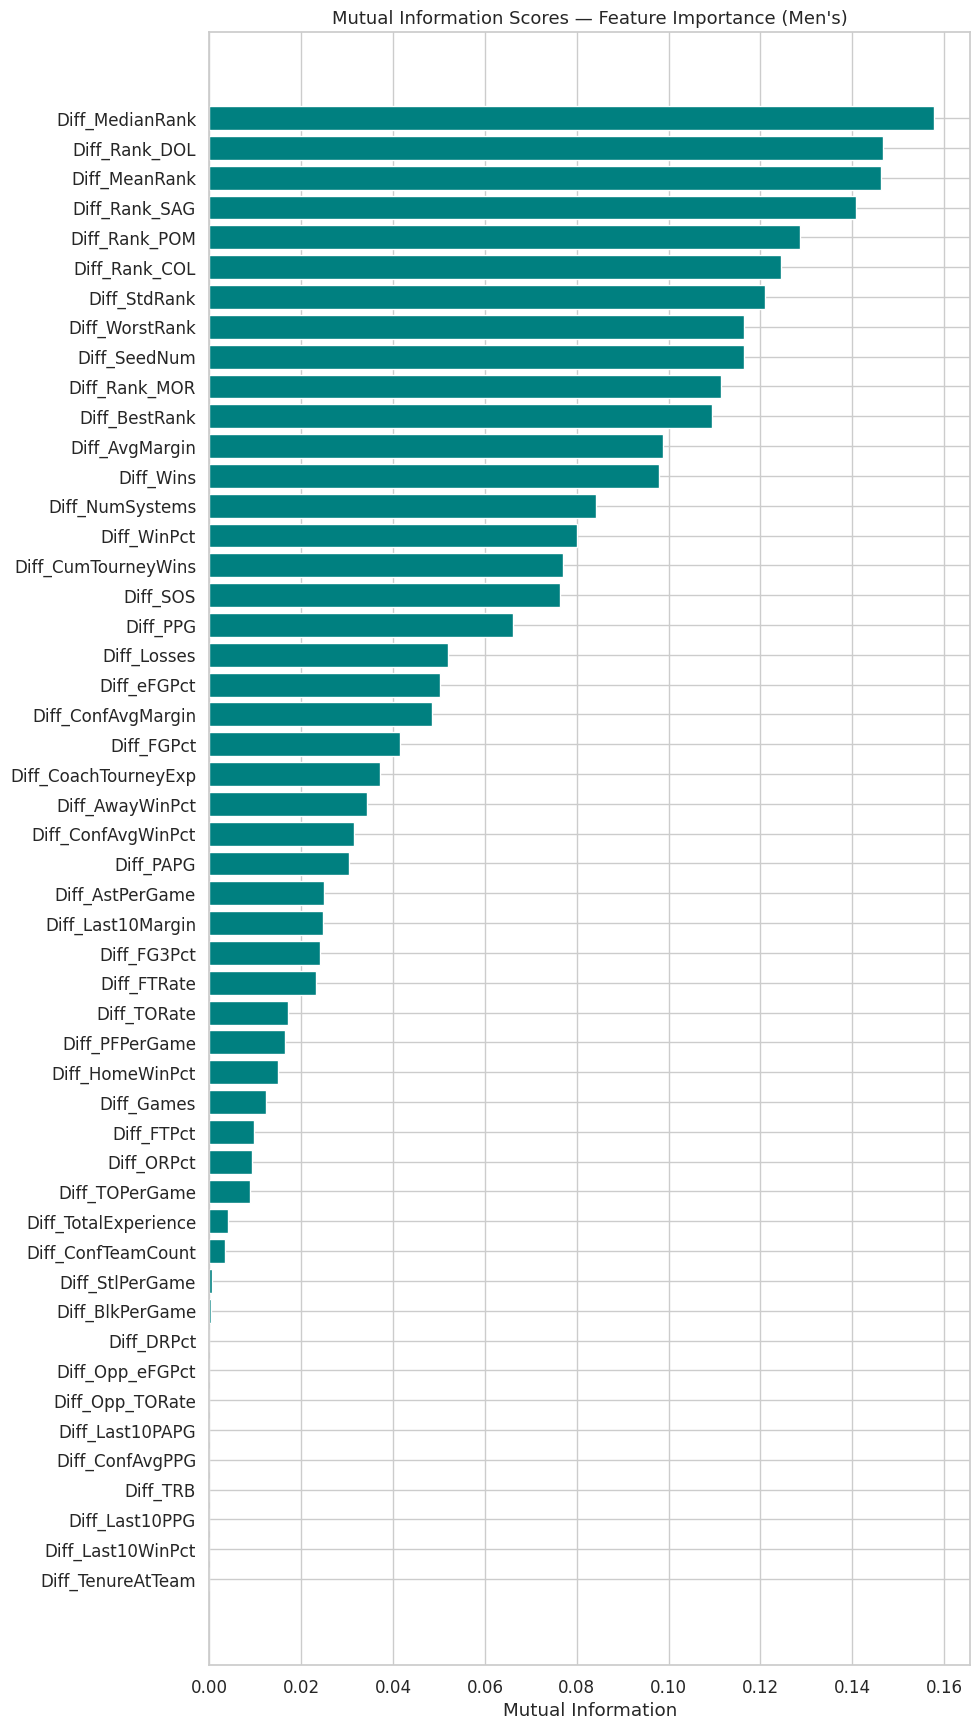

Top 10 features by Mutual Information:
        Feature  MI_Score
Diff_MedianRank  0.157828
  Diff_Rank_DOL  0.146709
  Diff_MeanRank  0.146262
  Diff_Rank_SAG  0.140908
  Diff_Rank_POM  0.128638
  Diff_Rank_COL  0.124510
   Diff_StdRank  0.120945
 Diff_WorstRank  0.116459
   Diff_SeedNum  0.116411
  Diff_Rank_MOR  0.111504


In [34]:
# ============================================================
# 6.2 MUTUAL INFORMATION — Non-linear feature importance
# ============================================================

X = analysis_df[diff_cols].fillna(0)
y = analysis_df["Target"]

mi_scores = mutual_info_classif(X, y, random_state=42, n_neighbors=5)
mi_df = pd.DataFrame({"Feature": diff_cols, "MI_Score": mi_scores}).sort_values("MI_Score", ascending=False)

fig, ax = plt.subplots(figsize=(10, max(8, len(mi_df) * 0.35)))
ax.barh(mi_df["Feature"][::-1], mi_df["MI_Score"][::-1], color="teal", edgecolor="white")
ax.set_title("Mutual Information Scores — Feature Importance (Men's)", fontsize=13)
ax.set_xlabel("Mutual Information")
plt.tight_layout()
plt.show()

print("Top 10 features by Mutual Information:")
print(mi_df.head(10).to_string(index=False))

Highly correlated feature pairs (|r| > 0.85): 49
  Diff_MeanRank                  ↔ Diff_MedianRank                 r=0.999
  Diff_Losses                    ↔ Diff_WinPct                     r=-0.993
  Diff_MedianRank                ↔ Diff_Rank_SAG                   r=0.991
  Diff_MeanRank                  ↔ Diff_Rank_SAG                   r=0.991
  Diff_MedianRank                ↔ Diff_Rank_DOL                   r=0.989
  Diff_MeanRank                  ↔ Diff_Rank_DOL                   r=0.989
  Diff_Rank_POM                  ↔ Diff_Rank_SAG                   r=0.986
  Diff_MeanRank                  ↔ Diff_Rank_COL                   r=0.986
  Diff_Rank_DOL                  ↔ Diff_Rank_COL                   r=0.985
  Diff_MeanRank                  ↔ Diff_Rank_POM                   r=0.985
  Diff_MedianRank                ↔ Diff_Rank_COL                   r=0.985
  Diff_MedianRank                ↔ Diff_Rank_POM                   r=0.984
  Diff_ConfAvgWinPct             ↔ Diff_ConfAvgMar

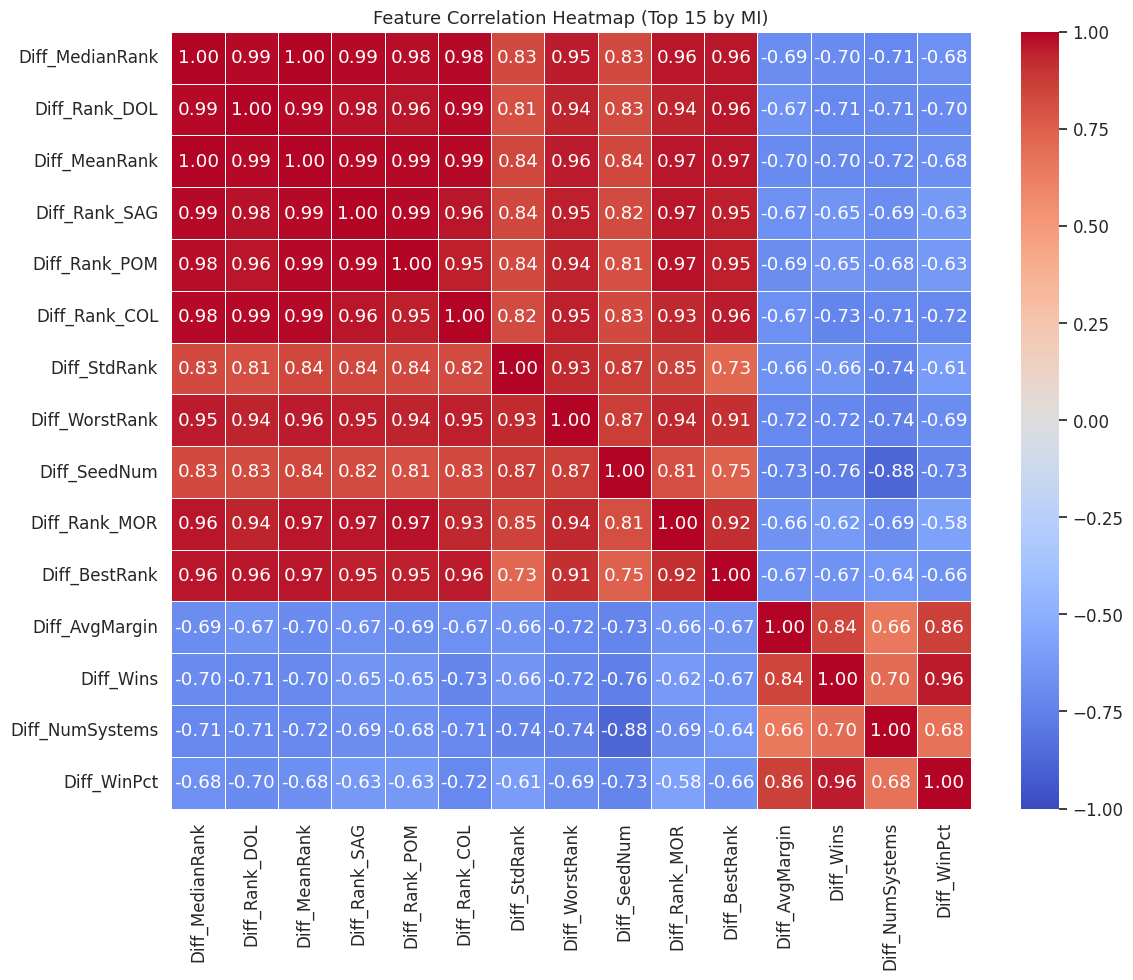

In [35]:
# ============================================================
# 6.3 MULTICOLLINEARITY — Feature Correlation Heatmap
# ============================================================

# Correlation matrix among diff features
corr_matrix = analysis_df[diff_cols].corr()

# Find highly correlated pairs (|r| > 0.85)
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i + 1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr_pairs.append((corr_matrix.index[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f"Highly correlated feature pairs (|r| > 0.85): {len(high_corr_pairs)}")
for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:15]:
    print(f"  {f1:30s} ↔ {f2:30s}  r={r:.3f}")

# Heatmap of top features
top_features = mi_df["Feature"].head(15).tolist()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(analysis_df[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Feature Correlation Heatmap (Top 15 by MI)", fontsize=13)
plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# 6.4 VARIANCE THRESHOLD — Remove near-zero variance features
# ============================================================
from sklearn.feature_selection import VarianceThreshold

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_scaled)
low_var = X_scaled.columns[~vt.get_support()].tolist()

print(f"Features with near-zero variance (threshold=0.01 on scaled data): {len(low_var)}")
if low_var:
    print(f"  → {low_var}")
else:
    print("  → None — all features pass the variance threshold")

# ============================================================
# 6.5 RECOMMENDED FEATURE SET
# ============================================================
# Combine insights: top MI, good correlation, not redundant
print("\n" + "="*60)
print("RECOMMENDED FEATURE SELECTION STRATEGY")
print("="*60)
print("""
1. Start with all Diff_ features
2. Remove low-variance features (if any)
3. For highly correlated pairs (|r|>0.85), keep the one with higher MI score
4. Top features by both correlation and MI are the strongest candidates
5. Rankings (MeanRank, specific system ranks) are typically most predictive
6. SeedNum difference is the single most important feature for tournament games
""")

Features with near-zero variance (threshold=0.01 on scaled data): 0
  → None — all features pass the variance threshold

RECOMMENDED FEATURE SELECTION STRATEGY

1. Start with all Diff_ features
2. Remove low-variance features (if any)
3. For highly correlated pairs (|r|>0.85), keep the one with higher MI score
4. Top features by both correlation and MI are the strongest candidates
5. Rankings (MeanRank, specific system ranks) are typically most predictive
6. SeedNum difference is the single most important feature for tournament games



---
## 7. Submission Skeleton

Parse the sample submission to understand what needs to be predicted, and prepare the prediction dataframe with features.

In [37]:
# ============================================================
# 7.1 PARSE SUBMISSION FORMAT
# ============================================================

def parse_submission(sub_df):
    """Parse the ID column into Season, Team1, Team2."""
    parsed = sub_df.copy()
    split = parsed["ID"].str.split("_", expand=True)
    parsed["Season"] = split[0].astype(int)
    parsed["Team1"]  = split[1].astype(int)
    parsed["Team2"]  = split[2].astype(int)
    # Determine gender: Men's teams are 1000-1999, Women's are 3000-3999
    parsed["Gender"] = np.where(parsed["Team1"] < 2000, "M", "W")
    return parsed

sub2_parsed = parse_submission(sub_stage2)
print(f"Stage 2 submission: {sub2_parsed.shape}")
print(f"  Seasons: {sub2_parsed['Season'].unique()}")
print(f"  Men's matchups:   {(sub2_parsed['Gender'] == 'M').sum():,}")
print(f"  Women's matchups: {(sub2_parsed['Gender'] == 'W').sum():,}")
print(f"  Unique Men's teams:   {sub2_parsed[sub2_parsed['Gender']=='M']['Team1'].nunique()}")
print(f"  Unique Women's teams: {sub2_parsed[sub2_parsed['Gender']=='W']['Team1'].nunique()}")
sub2_parsed.head()

Stage 2 submission: (132133, 6)
  Seasons: [2026]
  Men's matchups:   66,430
  Women's matchups: 65,703
  Unique Men's teams:   364
  Unique Women's teams: 362


,ID,Pred,Season,Team1,Team2,Gender
0,2026_1101_1102,0.5,2026,1101,1102,M
1,2026_1101_1103,0.5,2026,1101,1103,M
2,2026_1101_1104,0.5,2026,1101,1104,M
3,2026_1101_1105,0.5,2026,1101,1105,M
4,2026_1101_1106,0.5,2026,1101,1106,M


In [38]:
# ============================================================
# 7.2 MERGE FEATURES ONTO SUBMISSION (ready for model input)
# ============================================================

def prepare_prediction_df(sub_parsed, m_feat, w_feat):
    """Merge team features onto submission matchups."""
    # Split by gender
    m_sub = sub_parsed[sub_parsed["Gender"] == "M"].copy()
    w_sub = sub_parsed[sub_parsed["Gender"] == "W"].copy()
    
    drop_cols = ["Gender", "SeedRegion"]
    
    # Men's features
    m_f = m_feat.drop(columns=[c for c in drop_cols if c in m_feat.columns], errors="ignore")
    m_merged = m_sub.merge(m_f, left_on=["Season","Team1"], right_on=["Season","TeamID"], how="left").drop(columns="TeamID")
    m_merged = m_merged.merge(m_f, left_on=["Season","Team2"], right_on=["Season","TeamID"], how="left", suffixes=("_T1","_T2")).drop(columns="TeamID")
    
    # Women's features
    w_f = w_feat.drop(columns=[c for c in drop_cols if c in w_feat.columns], errors="ignore")
    w_merged = w_sub.merge(w_f, left_on=["Season","Team1"], right_on=["Season","TeamID"], how="left").drop(columns="TeamID")
    w_merged = w_merged.merge(w_f, left_on=["Season","Team2"], right_on=["Season","TeamID"], how="left", suffixes=("_T1","_T2")).drop(columns="TeamID")
    
    result = pd.concat([m_merged, w_merged], ignore_index=True)
    
    # Create diff features
    feat_cols = [c for c in m_f.columns if c not in ["Season","TeamID"]]
    for col in feat_cols:
        if f"{col}_T1" in result.columns and f"{col}_T2" in result.columns:
            result[f"Diff_{col}"] = result[f"{col}_T1"] - result[f"{col}_T2"]
    
    return result

pred_df = prepare_prediction_df(sub2_parsed, m_features, w_features)
print(f"Prediction dataframe: {pred_df.shape}")
print(f"Missing values in diff features:")
diff_missing = pred_df[[c for c in pred_df.columns if c.startswith("Diff_")]].isnull().mean()
print(diff_missing[diff_missing > 0].sort_values(ascending=False).head(10))
pred_df.head(3)

Prediction dataframe: (132133, 156)
Missing values in diff features:
Diff_MeanRank      1.0
Diff_MedianRank    1.0
Diff_BestRank      1.0
Diff_WorstRank     1.0
Diff_StdRank       1.0
Diff_NumSystems    1.0
Diff_Rank_POM      1.0
Diff_Rank_SAG      1.0
Diff_Rank_MOR      1.0
Diff_Rank_DOL      1.0
dtype: float64


,ID,Pred,Season,Team1,Team2,Gender,Wins_T1,Losses_T1,Games_T1,WinPct_T1,PPG_T1,PAPG_T1,AvgMargin_T1,HomeWinPct_T1,AwayWinPct_T1,eFGPct_T1,TORate_T1,ORPct_T1,FTRate_T1,DRPct_T1,Opp_eFGPct_T1,Opp_TORate_T1,AstPerGame_T1,StlPerGame_T1,BlkPerGame_T1,...,Diff_SOS,Diff_ConfAvgWinPct,Diff_ConfAvgPPG,Diff_ConfAvgMargin,Diff_ConfTeamCount,Diff_Last10WinPct,Diff_Last10PPG,Diff_Last10PAPG,Diff_Last10Margin,Diff_MeanRank,Diff_MedianRank,Diff_BestRank,Diff_WorstRank,Diff_StdRank,Diff_NumSystems,Diff_Rank_POM,Diff_Rank_SAG,Diff_Rank_MOR,Diff_Rank_DOL,Diff_Rank_COL,Diff_TenureAtTeam,Diff_TotalExperience,Diff_CoachTourneyExp,Diff_SeedNum,Diff_CumTourneyWins
0,2026_1101_1102,0.5,2026,1101,1102,M,10.0,16.0,26.0,0.384615,68.269231,73.346154,-5.076923,0.6,0.214286,0.476042,0.157953,0.288221,0.280556,0.743711,0.567277,0.183305,12.730769,7.230769,6.461538,...,-0.065252,-0.043217,-3.355520,-3.069832,-5,0.3,6.8,-15.2,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026_1101_1103,0.5,2026,1101,1103,M,10.0,16.0,26.0,0.384615,68.269231,73.346154,-5.076923,0.6,0.214286,0.476042,0.157953,0.288221,0.280556,0.743711,0.567277,0.183305,12.730769,7.230769,6.461538,...,0.023944,-0.000068,-4.539937,-1.025013,-6,-0.6,-13.8,-0.9,-12.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026_1101_1104,0.5,2026,1101,1104,M,10.0,16.0,26.0,0.384615,68.269231,73.346154,-5.076923,0.6,0.214286,0.476042,0.157953,0.288221,0.280556,0.743711,0.567277,0.183305,12.730769,7.230769,6.461538,...,-0.102726,-0.111378,-11.423857,-8.012482,-9,-0.6,-22.2,-12.7,-9.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 8. Summary & Next Steps

### Data Landscape
| Aspect | Men's | Women's |
|--------|-------|---------|
| Regular season games | ~198K (1985+) | ~142K (1998+) |
| Tournament games | ~2,585 | ~1,717 |
| Detailed box scores | 2003+ | 2010+ |
| Massey Rankings | ✅ (dozens of systems) | ❌ |
| Coaching data | ✅ | ❌ |

### Engineered Features (per team-season)
- **Basic stats**: Win%, PPG, PAPG, margin, home/away splits
- **Advanced (Four Factors)**: eFG%, TO rate, OR%, FT rate, DR%
- **Strength of Schedule**: Avg opponent win%
- **Conference**: Avg conference win%, PPG, margin
- **Recent form**: Last-10-games win%, scoring
- **Rankings**: Mean/median/best rank across Massey systems + specific systems (Men)
- **Coaching**: Tenure, experience, tournament experience (Men)
- **Tournament history**: Seed number, cumulative past tourney wins

### Recommended Next Steps
1. **Model training** — Use `m_matchups` / `w_matchups` as training data with `Diff_*` features
2. **Cross-validation** — Season-based CV (train on older seasons, validate on newer)
3. **Models to try** — Logistic Regression, LightGBM, XGBoost, Neural Nets
4. **Calibration** — Platt scaling or isotonic regression for probability calibration
5. **Ensembling** — Blend multiple models for robust predictions
6. **Generate submission** — Predict on `pred_df` and write to CSV